In [1]:
import time
notebook_start = time.perf_counter()

import os, json, pandas as pd, numpy as np, matplotlib.pyplot as plt, joblib, shap
import thermoift.PLOT_SETTINGS as ps

from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import LogLocator
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,mean_squared_error
from thermoift.rng_utils import get_rng
from thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics

n_cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", 4))
os.environ["OMP_NUM_THREADS"]      = str(n_cpus)
os.environ["MKL_NUM_THREADS"]      = str(n_cpus)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cpus)
os.environ["NUMEXPR_NUM_THREADS"]  = str(n_cpus)
print(f"Thread limit set to {n_cpus} (SLURM_CPUS_PER_TASK)")

Thread limit set to 64 (SLURM_CPUS_PER_TASK)


In [2]:
OUTPUT_FOLDER = "SVM_P_bubble_OUTPUTS"
SEED          = 50015
TEST_ROWS     = None


In [3]:
# Parameters
OUTPUT_FOLDER = "SLURM_Pbubble"
TEST_ROWS = None
SEED = 50015


In [4]:
df = pd.read_csv("../interfacial_results_dataset_A4.csv")

if isinstance(TEST_ROWS, str) and TEST_ROWS.strip().lower() in ("", "none", "null"):
    TEST_ROWS = None
if TEST_ROWS is not None:
    TEST_ROWS = int(TEST_ROWS)
    df = df.iloc[:TEST_ROWS].copy()
    print(f"Test mode: using first {TEST_ROWS} rows only")

print(f"Total samples: {len(df)}")
print(f"\nP_bubble statistics:")
print(df["P_bubble"].describe())

Total samples: 19361

P_bubble statistics:
count    19361.000000
mean        41.311216
std         21.196807
min          3.338831
25%         24.499412
50%         38.379096
75%         56.527415
max        162.875312
Name: P_bubble, dtype: float64


In [5]:
target     = "P_bubble"
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:      {X_test.shape[0]}")
print(f"Validation samples:   {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13552
Testing samples:      2904
Validation samples:   2905


In [6]:
# plot_correlation_heatmap(df, features, target, save_path="SVM_P_bubble_correlation", folder=OUTPUT_FOLDER)

In [7]:
# Train SVM model (SVR)
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",       # radial basis function — best general-purpose kernel
        C=100,              # regularisation: higher = tighter fit, lower = smoother
        epsilon=0.1,        # insensitive tube half-width (in scaled units)
        # gamma="scale",      # 1 / (n_features * X.var()), auto-tuned
    ))
])

svm_model.fit(X_train, y_train)

y_train_pred    = svm_model.predict(X_train)
y_test_pred     = svm_model.predict(X_test)
y_val_pred      = svm_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, y_val=y_val, y_val_pred=y_val_pred)

Model Performance for P_bubble

Training Set:
  R²:   0.999678
  RMSE: 0.377856 bar
  MAE:  0.085926 bar

Test Set:
  R²:   0.999408
  RMSE: 0.532407 bar
  MAE:  0.107409 bar

Validation Set:
  R²:   0.999729
  RMSE: 0.348108 bar
  MAE:  0.091898 bar


In [8]:
results_df = pd.DataFrame({
    "idx": np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual": np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred, y_test_pred, y_val_pred]),
    "split": ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(OUTPUT_FOLDER, f"SVM_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save fitted model for future use without retraining
model_path = os.path.join(OUTPUT_FOLDER, f"SVM_{target}_model.joblib")
joblib.dump(svm_model, model_path)
print(f"Model saved to: {model_path}")

Predictions saved: 19361 rows
Model saved to: SLURM_Pbubble/SVM_P_bubble_model.joblib


In [9]:
# 5-fold cross-validation
cv_results = cross_validate(
    svm_model, X, y, cv=5,
    scoring={
        "r2":   "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae":  "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
    },
    n_jobs=n_cpus,
)
cv_r2_scores   = cv_results["test_r2"]
cv_rmse_scores = -cv_results["test_rmse"]
cv_mae_scores  = -cv_results["test_mae"]
cv_mape_scores = -cv_results["test_mape"]

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAE Scores:  {cv_mae_scores}")
print(f"Mean CV MAE:  {cv_mae_scores.mean():.6f} (+/- {cv_mae_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAPE Scores: {cv_mape_scores * 100}")
print(f"Mean CV MAPE: {cv_mape_scores.mean() * 100:.4f}% (+/- {cv_mape_scores.std() * 2 * 100:.4f}%)")

Cross-Validation R² Scores:   [0.98966902 0.88384381 0.99316036 0.9233858  0.91078682]
Mean CV R²:   0.940169 (+/- 0.087525)

Cross-Validation RMSE Scores: [2.04692917 7.96612864 1.82959327 5.73492696 5.71049234]
Mean CV RMSE: 4.657614 (+/- 4.735297)

Cross-Validation MAE Scores:  [1.18716882 3.4395959  1.15445381 3.35063619 3.04600178]
Mean CV MAE:  2.435571 (+/- 2.081885)

Cross-Validation MAPE Scores: [ 6.93681879 13.95614181  4.3726941  12.16209287 11.7370906 ]
Mean CV MAPE: 9.8330% (+/- 7.1696%)


C sweep complete.
  C=   0.01 | Train RMSE=15.8976  CV RMSE=16.8335  Test RMSE=16.7277  SVs=13478
  C=    0.1 | Train RMSE=7.4850  CV RMSE=8.1006  Test RMSE=8.1787  SVs=13120
  C=      1 | Train RMSE=3.1786  CV RMSE=3.5048  Test RMSE=3.5637  SVs=11088
  C=     10 | Train RMSE=1.0751  CV RMSE=1.2469  Test RMSE=1.3486  SVs=5993
  C=    100 | Train RMSE=0.3779  CV RMSE=0.4785  Test RMSE=0.5324  SVs=2328
  C=    500 | Train RMSE=0.1543  CV RMSE=0.2460  Test RMSE=0.2646  SVs=1318
  C=   1000 | Train RMSE=0.1132  CV RMSE=0.1867  Test RMSE=0.2041  SVs=1143
  C=   5000 | Train RMSE=0.0716  CV RMSE=0.1134  Test RMSE=0.1264  SVs=914


/tmp/ipykernel_1545386/1943184778.py:52: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.tight_layout()
/tmp/ipykernel_1545386/1943184778.py:52: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.tight_layout()


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/PLOT_SETTINGS.py:227: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.savefig(file_path, dpi=resolution_value, bbox_inches='tight')


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/PLOT_SETTINGS.py:228: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.savefig(fr"{filename}", dpi=resolution_value, bbox_inches='tight')


/home/darshan/A6/py_A6/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


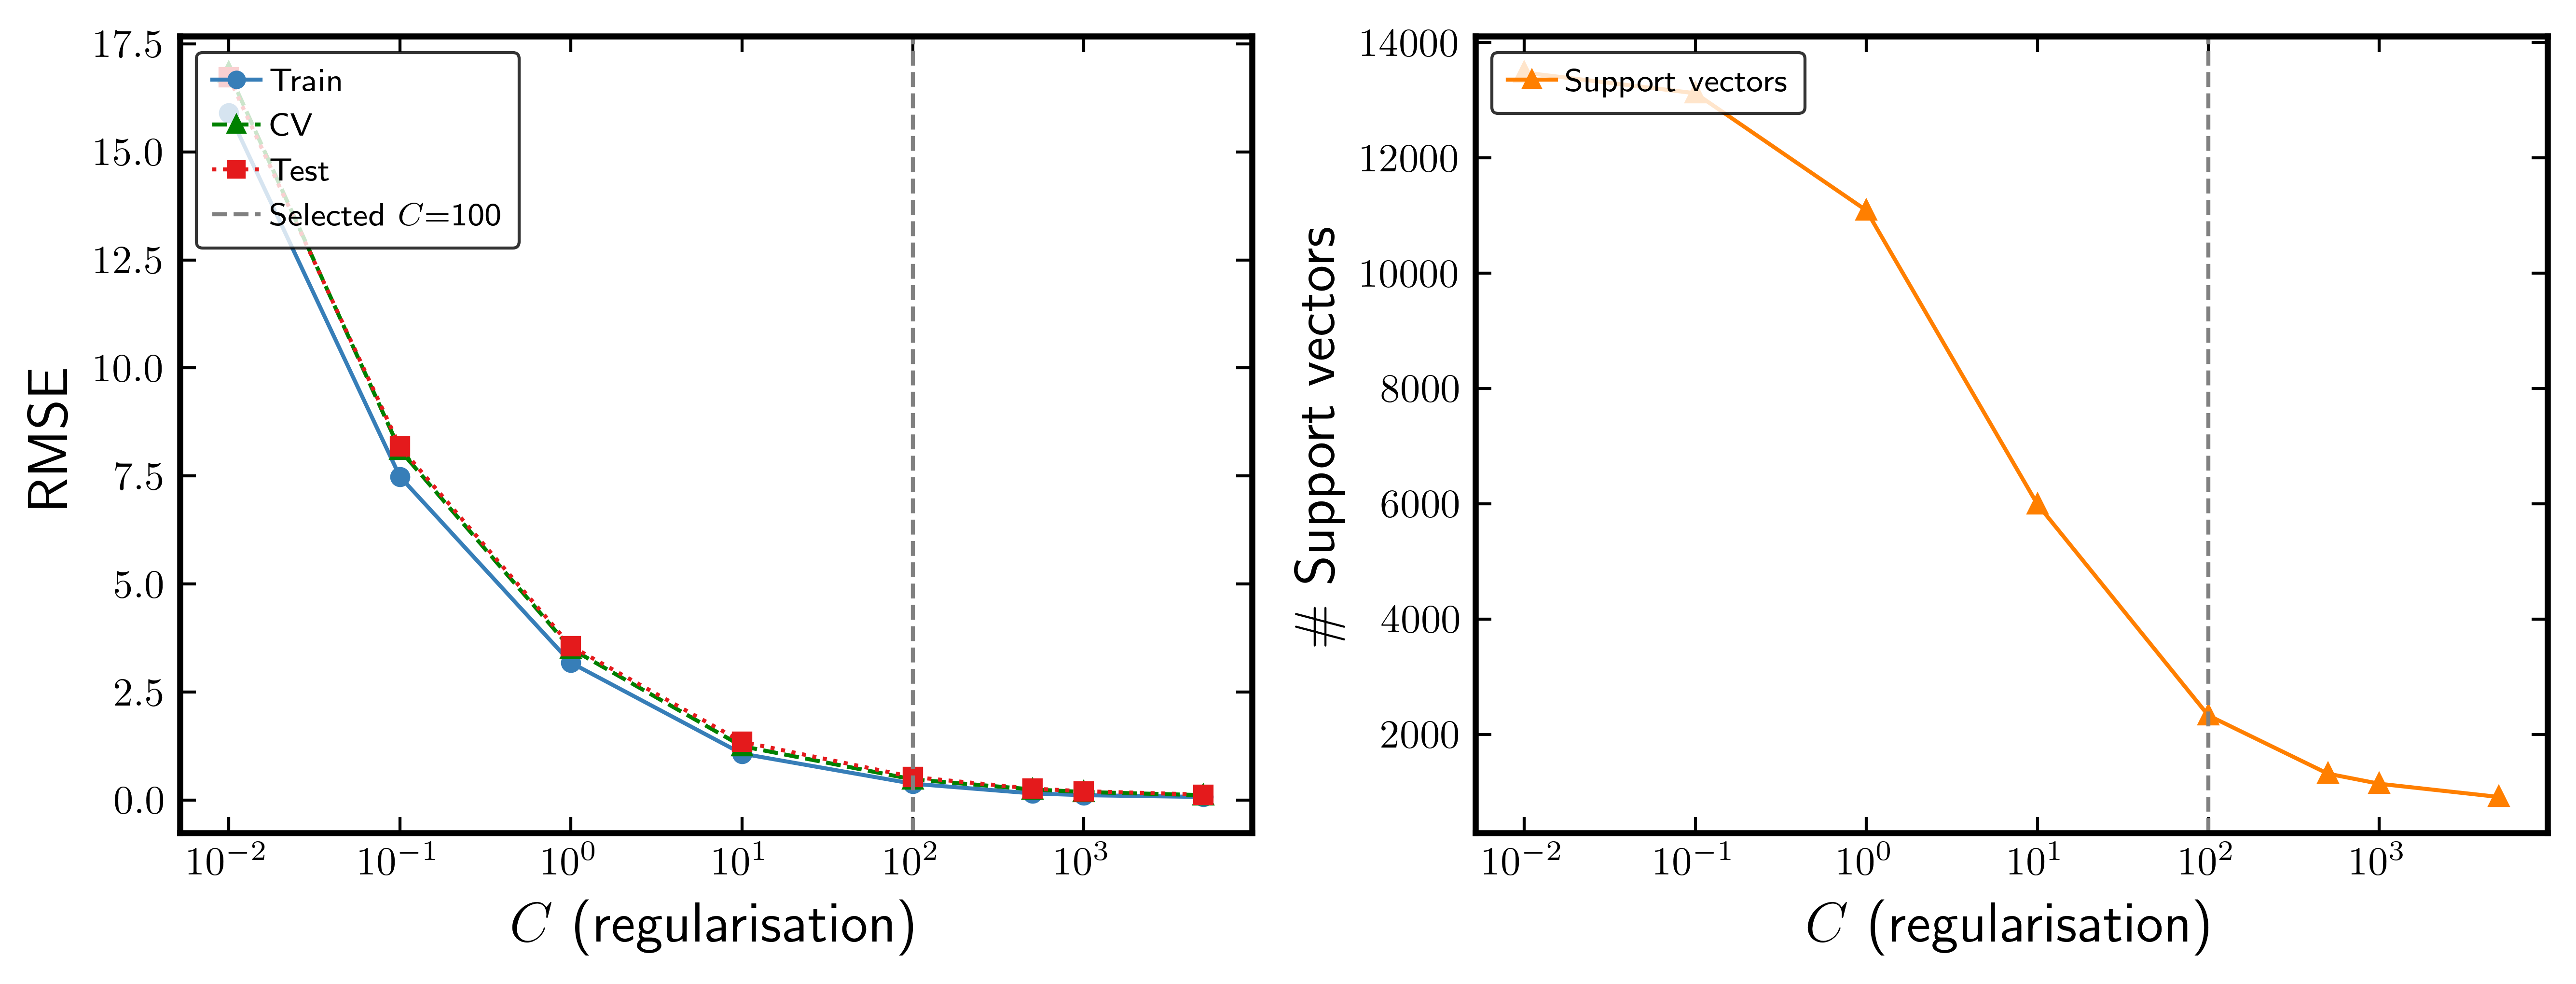

Saved: SVM_P_bubble_C_sweep


In [10]:
# Hyperparameter analysis: C sensitivity sweep (SVR)
# Hyperparameter comparison uses 5-fold CV RMSE; test RMSE is shown only as a holdout reference.
C_values = [0.01, 0.1, 1, 10, 100, 500, 1000, 5000]
selected_kernel = svm_model.named_steps["svr"].kernel
selected_epsilon = svm_model.named_steps["svr"].epsilon

train_rmse_C, cv_rmse_C, test_rmse_C, sv_count_C = [], [], [], []
for _C in C_values:
    _model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel=selected_kernel, C=_C, epsilon=selected_epsilon)),
    ])
    _model.fit(X_train, y_train)
    train_rmse_C.append(np.sqrt(mean_squared_error(y_train, _model.predict(X_train))))
    test_rmse_C.append(np.sqrt(mean_squared_error(y_test,  _model.predict(X_test))))
    sv_count_C.append(_model.named_steps["svr"].support_vectors_.shape[0])
    _cv = cross_validate(
        _model, X_train, y_train, cv=5,
        scoring={"rmse": "neg_root_mean_squared_error"},
        n_jobs=n_cpus,
    )
    cv_rmse_C.append(float(-_cv["test_rmse"].mean()))

print("C sweep complete.")
for _C, tr, cv, te, sv in zip(C_values, train_rmse_C, cv_rmse_C, test_rmse_C, sv_count_C):
    print(f"  C={_C:>7} | Train RMSE={tr:.4f}  CV RMSE={cv:.4f}  Test RMSE={te:.4f}  SVs={sv}")

fig, axes = ps.plot_init_multi(1, 2, w=9, h=3.5)
ax_rmse, ax_sv = axes

ax_rmse.semilogx(C_values, train_rmse_C, marker="o", markersize=ps.markersize,
                 lw=ps.linewidth, color=ps.colors[2], label="Train")
ax_rmse.semilogx(C_values, cv_rmse_C, marker="^", markersize=ps.markersize,
                 lw=ps.linewidth, color=ps.colors[1], label="CV")
ax_rmse.semilogx(C_values, test_rmse_C,  marker="s", markersize=ps.markersize,
                 lw=ps.linewidth, color=ps.colors[0], label="Test")
ax_rmse.axvline(svm_model.named_steps["svr"].C, ls="--", color="gray",
                lw=ps.linewidth, label=f'Selected $C$={svm_model.named_steps["svr"].C}')
ax_rmse.set_xlabel(r"$C$ (regularisation)", fontsize=ps.label_fontsize)
ax_rmse.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax_rmse.xaxis.set_minor_locator(AutoMinorLocator(2))
ps.style_legend(ax_rmse, loc="upper left")

ax_sv.semilogx(C_values, sv_count_C, marker="^", markersize=ps.markersize,
               lw=ps.linewidth, color=ps.colors[3], label="Support vectors")
ax_sv.axvline(svm_model.named_steps["svr"].C, ls="--", color="gray", lw=ps.linewidth)
ax_sv.set_xlabel(r"$C$ (regularisation)", fontsize=ps.label_fontsize)
ax_sv.set_ylabel(r"\# Support vectors", fontsize=ps.label_fontsize)
ax_sv.xaxis.set_minor_locator(AutoMinorLocator(2))
ps.style_legend(ax_sv, loc="upper left")

plt.tight_layout()
ps.save_plot(fig, f"SVM_{target}_C_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: SVM_{target}_C_sweep")


Epsilon sweep complete.
  eps=0.001 | Train RMSE=0.3663  CV RMSE=0.4718  Test RMSE=0.5200  SVs=12448
  eps=0.005 | Train RMSE=0.3663  CV RMSE=0.4718  Test RMSE=0.5210  SVs=9732
  eps=0.010 | Train RMSE=0.3668  CV RMSE=0.4719  Test RMSE=0.5219  SVs=7859
  eps=0.050 | Train RMSE=0.3709  CV RMSE=0.4738  Test RMSE=0.5256  SVs=3596
  eps=0.100 | Train RMSE=0.3779  CV RMSE=0.4785  Test RMSE=0.5324  SVs=2328
  eps=0.500 | Train RMSE=0.4539  CV RMSE=0.5539  Test RMSE=0.5867  SVs=821
  eps=1.000 | Train RMSE=0.6338  CV RMSE=0.7351  Test RMSE=0.7438  SVs=504
  eps=2.000 | Train RMSE=1.0811  CV RMSE=1.1549  Test RMSE=1.1585  SVs=311


/tmp/ipykernel_1545386/1048131816.py:53: UserWarning: AutoMinorLocator does not work on logarithmic scales
  plt.tight_layout()


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/PLOT_SETTINGS.py:227: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.savefig(file_path, dpi=resolution_value, bbox_inches='tight')


/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/PLOT_SETTINGS.py:228: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.savefig(fr"{filename}", dpi=resolution_value, bbox_inches='tight')


/home/darshan/A6/py_A6/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


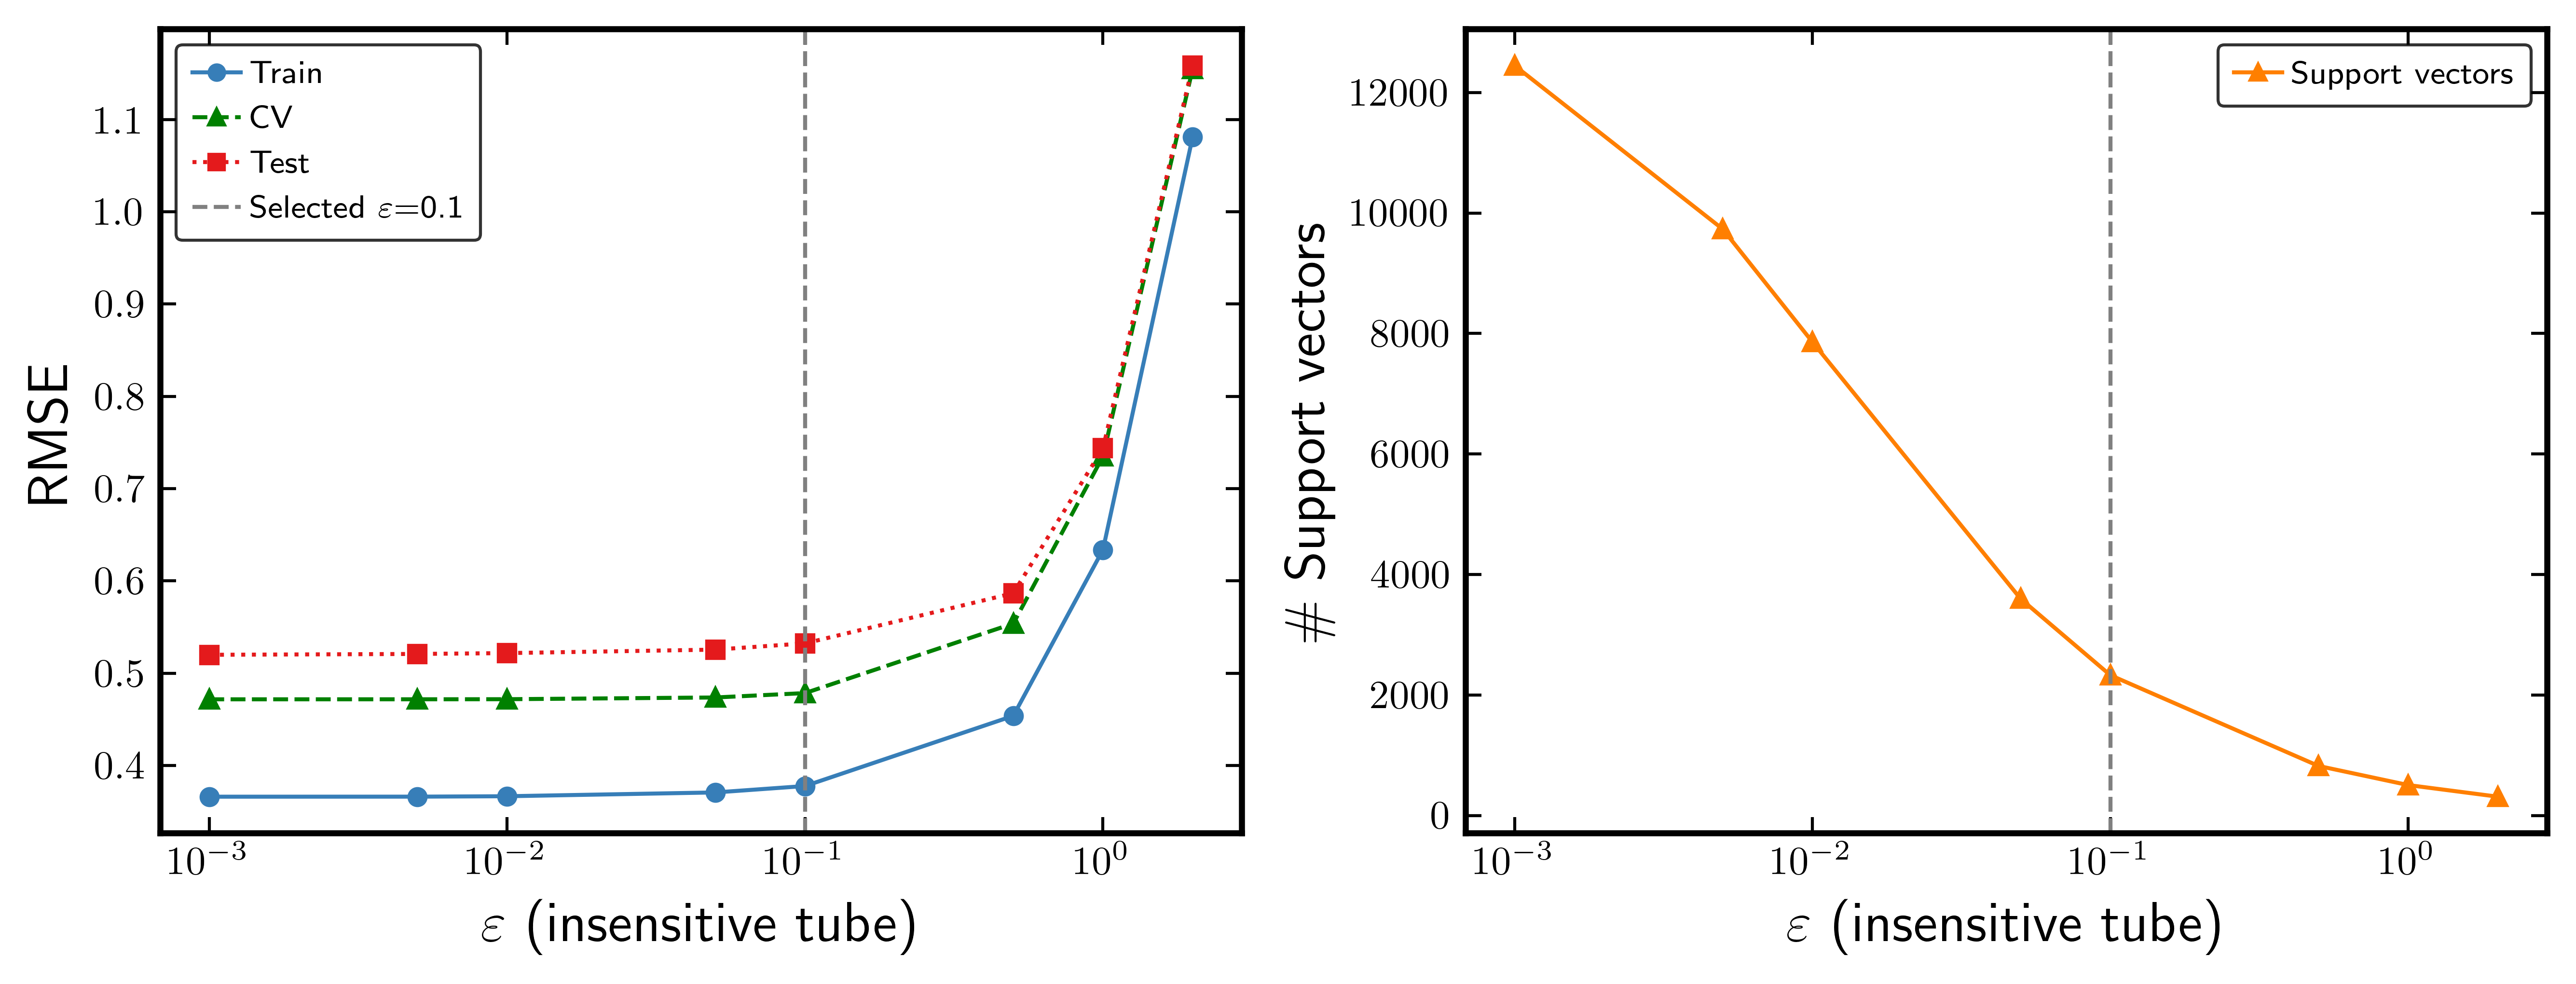

Saved: SVM_P_bubble_epsilon_sweep


In [11]:
# Hyperparameter analysis: epsilon sensitivity sweep (SVR)
# Hyperparameter comparison uses 5-fold CV RMSE; test RMSE is shown only as a holdout reference.
eps_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
C_fixed = svm_model.named_steps["svr"].C
selected_kernel = svm_model.named_steps["svr"].kernel

train_rmse_eps, cv_rmse_eps, test_rmse_eps, sv_count_eps = [], [], [], []
for _eps in eps_values:
    _model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel=selected_kernel, C=C_fixed, epsilon=_eps)),
    ])
    _model.fit(X_train, y_train)
    train_rmse_eps.append(np.sqrt(mean_squared_error(y_train, _model.predict(X_train))))
    test_rmse_eps.append(np.sqrt(mean_squared_error(y_test,  _model.predict(X_test))))
    sv_count_eps.append(_model.named_steps["svr"].support_vectors_.shape[0])
    _cv = cross_validate(
        _model, X_train, y_train, cv=5,
        scoring={"rmse": "neg_root_mean_squared_error"},
        n_jobs=n_cpus,
    )
    cv_rmse_eps.append(float(-_cv["test_rmse"].mean()))

print("Epsilon sweep complete.")
for _e, tr, cv, te, sv in zip(eps_values, train_rmse_eps, cv_rmse_eps, test_rmse_eps, sv_count_eps):
    print(f"  eps={_e:.3f} | Train RMSE={tr:.4f}  CV RMSE={cv:.4f}  Test RMSE={te:.4f}  SVs={sv}")

fig, axes = ps.plot_init_multi(1, 2, w=9, h=3.5)
ax_r, ax_s = axes

ax_r.semilogx(eps_values, train_rmse_eps, marker="o", markersize=ps.markersize,
              lw=ps.linewidth, color=ps.colors[2], label="Train")
ax_r.semilogx(eps_values, cv_rmse_eps, marker="^", markersize=ps.markersize,
              lw=ps.linewidth, color=ps.colors[1], label="CV")
ax_r.semilogx(eps_values, test_rmse_eps,  marker="s", markersize=ps.markersize,
              lw=ps.linewidth, color=ps.colors[0], label="Test")
ax_r.axvline(svm_model.named_steps["svr"].epsilon, ls="--", color="gray",
             lw=ps.linewidth,
             label=rf'Selected $\varepsilon$={svm_model.named_steps["svr"].epsilon}')
ax_r.set_xlabel(r"$\varepsilon$ (insensitive tube)", fontsize=ps.label_fontsize)
ax_r.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax_r.xaxis.set_minor_locator(AutoMinorLocator(2))
ps.style_legend(ax_r, loc="upper left")

ax_s.semilogx(eps_values, sv_count_eps, marker="^", markersize=ps.markersize,
              lw=ps.linewidth, color=ps.colors[3], label="Support vectors")
ax_s.axvline(svm_model.named_steps["svr"].epsilon, ls="--", color="gray", lw=ps.linewidth)
ax_s.set_xlabel(r"$\varepsilon$ (insensitive tube)", fontsize=ps.label_fontsize)
ax_s.set_ylabel(r"\# Support vectors", fontsize=ps.label_fontsize)
ax_s.xaxis.set_minor_locator(AutoMinorLocator(2))
ps.style_legend(ax_s, loc="upper right")

plt.tight_layout()
ps.save_plot(fig, f"SVM_{target}_epsilon_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: SVM_{target}_epsilon_sweep")


Outlier threshold (3σ): ±1.201758
Test outliers: 23/2904 (0.79%)
Val  outliers: 17/2905  (0.59%)
Saved: SVM_P_bubble_outliers.csv (40 rows)
  idx split  source_id  temperature   pressure     actual  predicted  residual
 9684  test         50        200.0  55.556597 121.635785 113.035758  8.600027
 4648  test         24        205.0  23.629725  94.263072  92.783188  1.479884
 4086  test         21        215.0 119.121632 119.121732 123.073986 -3.952254
 4072  test         21        210.0  46.542001 130.851954 128.672794  2.179160
19166  test         99        200.0   2.680295  89.307022  87.550630  1.756392
 1921  test         10        200.0  39.047522 111.665700 110.195078  1.470622
 9685  test         50        200.0  68.772414 121.635785 112.918220  8.717565
 9697  test         50        210.0   4.341598  96.541715  94.703523  1.838192
 9680  test         50        200.0   2.693326 121.635785 111.251255 10.384530
 4053  test         21        200.0   2.719736 162.875312 145.941392 1

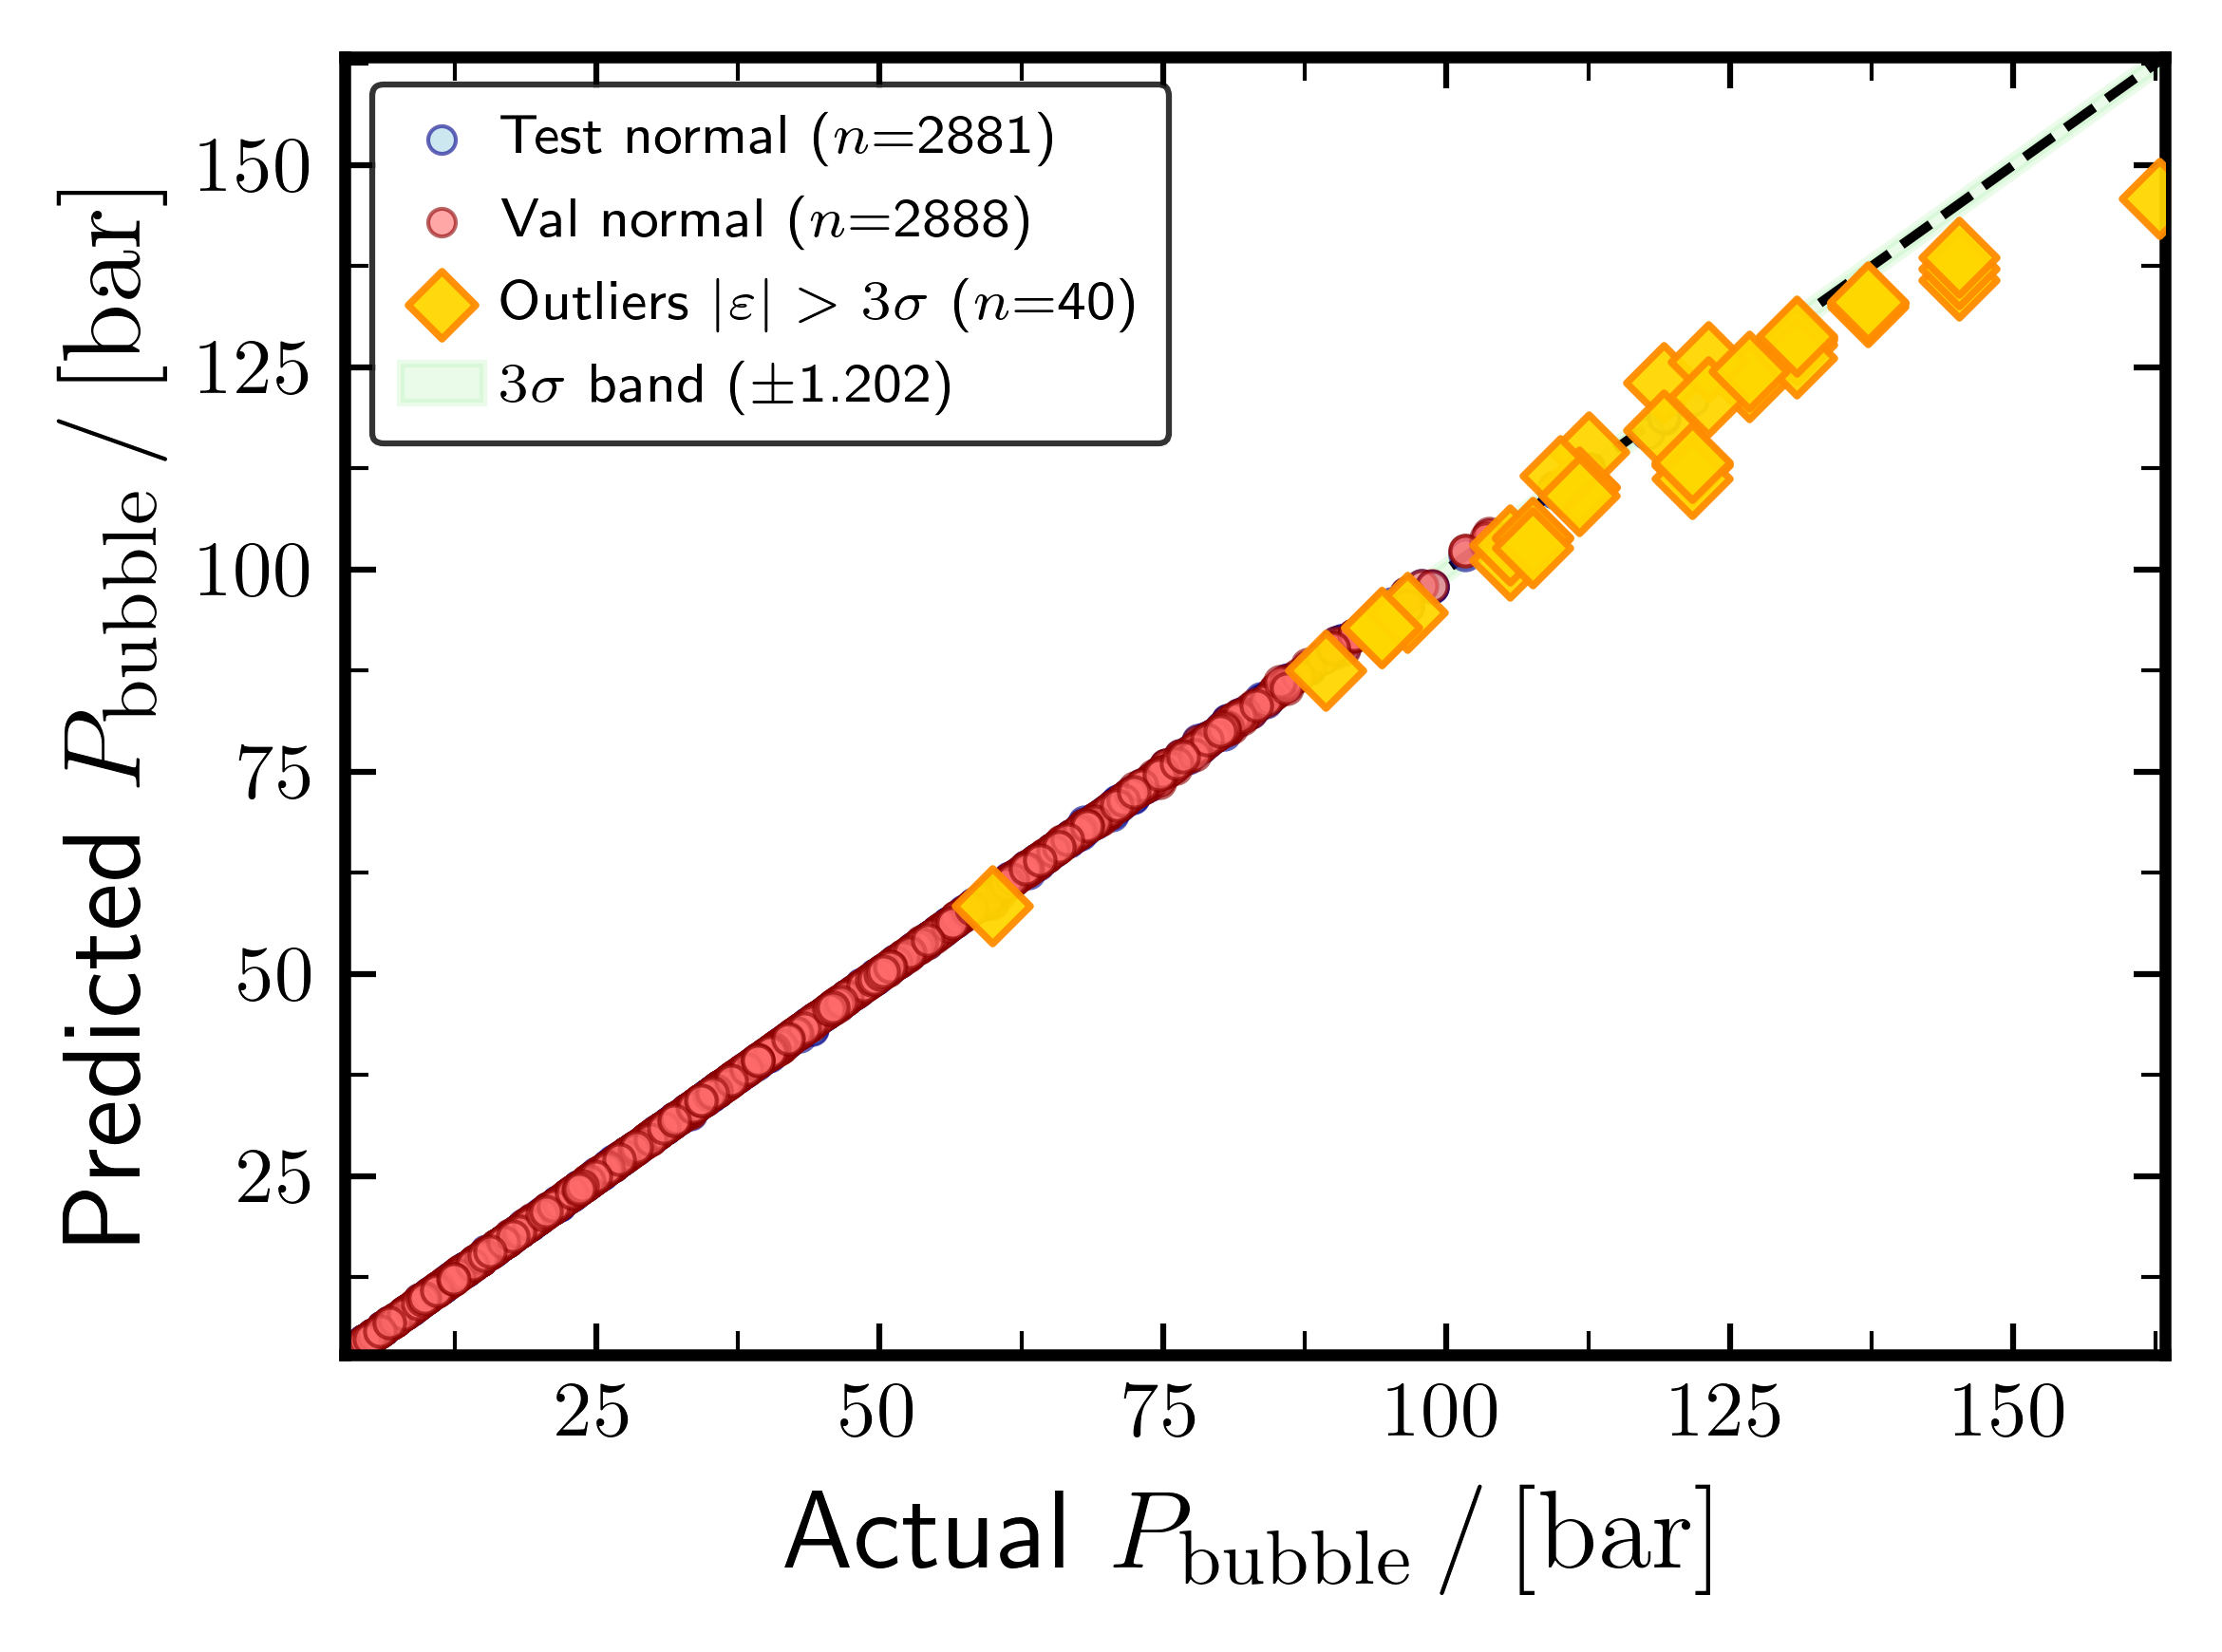

Saved: SVM_P_bubble_outlier_parity


In [12]:
# Outlier flagging: test + val samples where |residual| > 3 * global std

all_resids_global = np.concatenate([
    np.asarray(y_train) - y_train_pred,
    np.asarray(y_test)  - y_test_pred,
    np.asarray(y_val)   - y_val_pred,
])
threshold = 3.0 * all_resids_global.std()

test_resids   = np.asarray(y_test) - y_test_pred
val_resids    = np.asarray(y_val)  - y_val_pred
test_out_mask = np.abs(test_resids) > threshold
val_out_mask  = np.abs(val_resids)  > threshold

n_test_out = int(test_out_mask.sum())
n_val_out  = int(val_out_mask.sum())
print(f"Outlier threshold (3\u03c3): \u00b1{threshold:.6f}")
print(f"Test outliers: {n_test_out}/{len(y_test)} ({100*n_test_out/len(y_test):.2f}%)")
print(f"Val  outliers: {n_val_out}/{len(y_val)}  ({100*n_val_out/len(y_val):.2f}%)")

outlier_df = pd.concat([
    pd.DataFrame({
        "idx":         y_test.index[test_out_mask],
        "split":       "test",
        "source_id":   df.loc[y_test.index[test_out_mask], "source_id"].values,
        "temperature": df.loc[y_test.index[test_out_mask], "temperature"].values,
        "pressure":    df.loc[y_test.index[test_out_mask], "pressure"].values,
        "actual":      np.asarray(y_test)[test_out_mask],
        "predicted":   y_test_pred[test_out_mask],
        "residual":    test_resids[test_out_mask],
    }),
    pd.DataFrame({
        "idx":         y_val.index[val_out_mask],
        "split":       "val",
        "source_id":   df.loc[y_val.index[val_out_mask], "source_id"].values,
        "temperature": df.loc[y_val.index[val_out_mask], "temperature"].values,
        "pressure":    df.loc[y_val.index[val_out_mask], "pressure"].values,
        "actual":      np.asarray(y_val)[val_out_mask],
        "predicted":   y_val_pred[val_out_mask],
        "residual":    val_resids[val_out_mask],
    }),
], ignore_index=True)
outlier_df.to_csv(os.path.join(OUTPUT_FOLDER, f"SVM_{target}_outliers.csv"), index=False)
print(f"Saved: SVM_{target}_outliers.csv ({len(outlier_df)} rows)")
print(outlier_df.to_string(index=False))

# Parity plot highlighting outliers
fig, ax = ps.plot_init()

for y_true_sp, y_pred_sp, out_mask, fc, ec, lbl in [
    (y_test, y_test_pred, test_out_mask, "lightblue", "darkblue", "Test"),
    (y_val,  y_val_pred,  val_out_mask,  "#FF6B6B",   "darkred",  "Val"),
]:
    norm = ~out_mask
    ax.scatter(
        np.asarray(y_true_sp)[norm], y_pred_sp[norm],
        alpha=0.6, s=15, facecolors=fc, edgecolors=ec,
        linewidths=0.5, zorder=2,
        label=rf"{lbl} normal ($n$={int(norm.sum())})",
    )

all_out_true = np.concatenate([np.asarray(y_test)[test_out_mask], np.asarray(y_val)[val_out_mask]])
all_out_pred = np.concatenate([y_test_pred[test_out_mask], y_val_pred[val_out_mask]])
if len(all_out_true) > 0:
    ax.scatter(
        all_out_true, all_out_pred,
        alpha=0.95, s=45, facecolors="gold", edgecolors="darkorange",
        linewidths=0.9, marker="D", zorder=4,
        label=rf"Outliers $|\varepsilon|>3\sigma$ ($n$={len(all_out_true)})",
    )

all_vals = np.concatenate([np.asarray(y_test), np.asarray(y_val), y_test_pred, y_val_pred])
lims     = [all_vals.min() - 0.5, all_vals.max() + 0.5]
x_line   = np.array(lims)
ax.fill_between(x_line, x_line - threshold, x_line + threshold,
                color="lightgreen", alpha=0.18, zorder=0,
                label=rf"$3\sigma$ band ($\pm${threshold:.3f})")
ax.plot(lims, lims, "k--", lw=1.2, zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

target_label_str = ps.label_map.get(target.lower(), target)
ax.set_xlabel(f"Actual {target_label_str}", fontsize=ps.label_fontsize)
ax.set_ylabel(f"Predicted {target_label_str}", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper left', fontsize=ps.label_fontsize * 0.5)
plt.tight_layout()
ps.save_plot(fig, f"SVM_{target}_outlier_parity", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: SVM_{target}_outlier_parity")

In [13]:
label_map = {
    "temperature":           r"$T$",
    "pressure":              r"$P$",
    "z_carbon dioxide":      r"$z_{\mathrm{CO_2}}$",
    "z_hydrogen":            r"$z_{\mathrm{H_2}}$",
    "z_argon":               r"$z_{\mathrm{Ar}}$",
    "z_nitrogen":            r"$z_{\mathrm{N_2}}$",
    "z_methane":             r"$z_{\mathrm{CH_4}}$",
    "z_oxygen":              r"$z_{\mathrm{O_2}}$",
    "z_carbon monoxide":     r"$z_{\mathrm{CO}}$",
    "z_hydrogen sulfide":    r"$z_{\mathrm{H_2S}}$",
    "P_dew":                 r"$P_{\mathrm{dew}}$",
    "P_bubble":              r"$P_{\mathrm{bubble}}$",
    "gamma":                 r"$\gamma$",
    "interfacial_thickness": r"$\ell_{\mathrm{if}}$",
}

scaler_step    = svm_model.named_steps["scaler"]
svr_step       = svm_model.named_steps["svr"]
X_train_scaled = scaler_step.transform(X_train)
X_test_scaled  = scaler_step.transform(X_test)
feature_labels = [label_map.get(f, f) for f in features]
kernel         = svr_step.kernel

if kernel == "linear":
    explainer   = shap.LinearExplainer(svr_step, X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
else:
    # KernelExplainer works for any kernel; cap to 500 samples to keep runtime tractable
    _bg         = shap.kmeans(X_train_scaled, 50)
    explainer   = shap.KernelExplainer(svr_step.predict, _bg)
    _n          = min(500, len(X_test_scaled))
    shap_values = explainer.shap_values(X_test_scaled[:_n], silent=True)

shap_df             = pd.DataFrame(shap_values, columns=feature_labels)
feature_importances = np.abs(shap_df).mean().values
print(f"SHAP computed ({kernel} kernel, {len(shap_df)} samples)")

SHAP computed (rbf kernel, 500 samples)


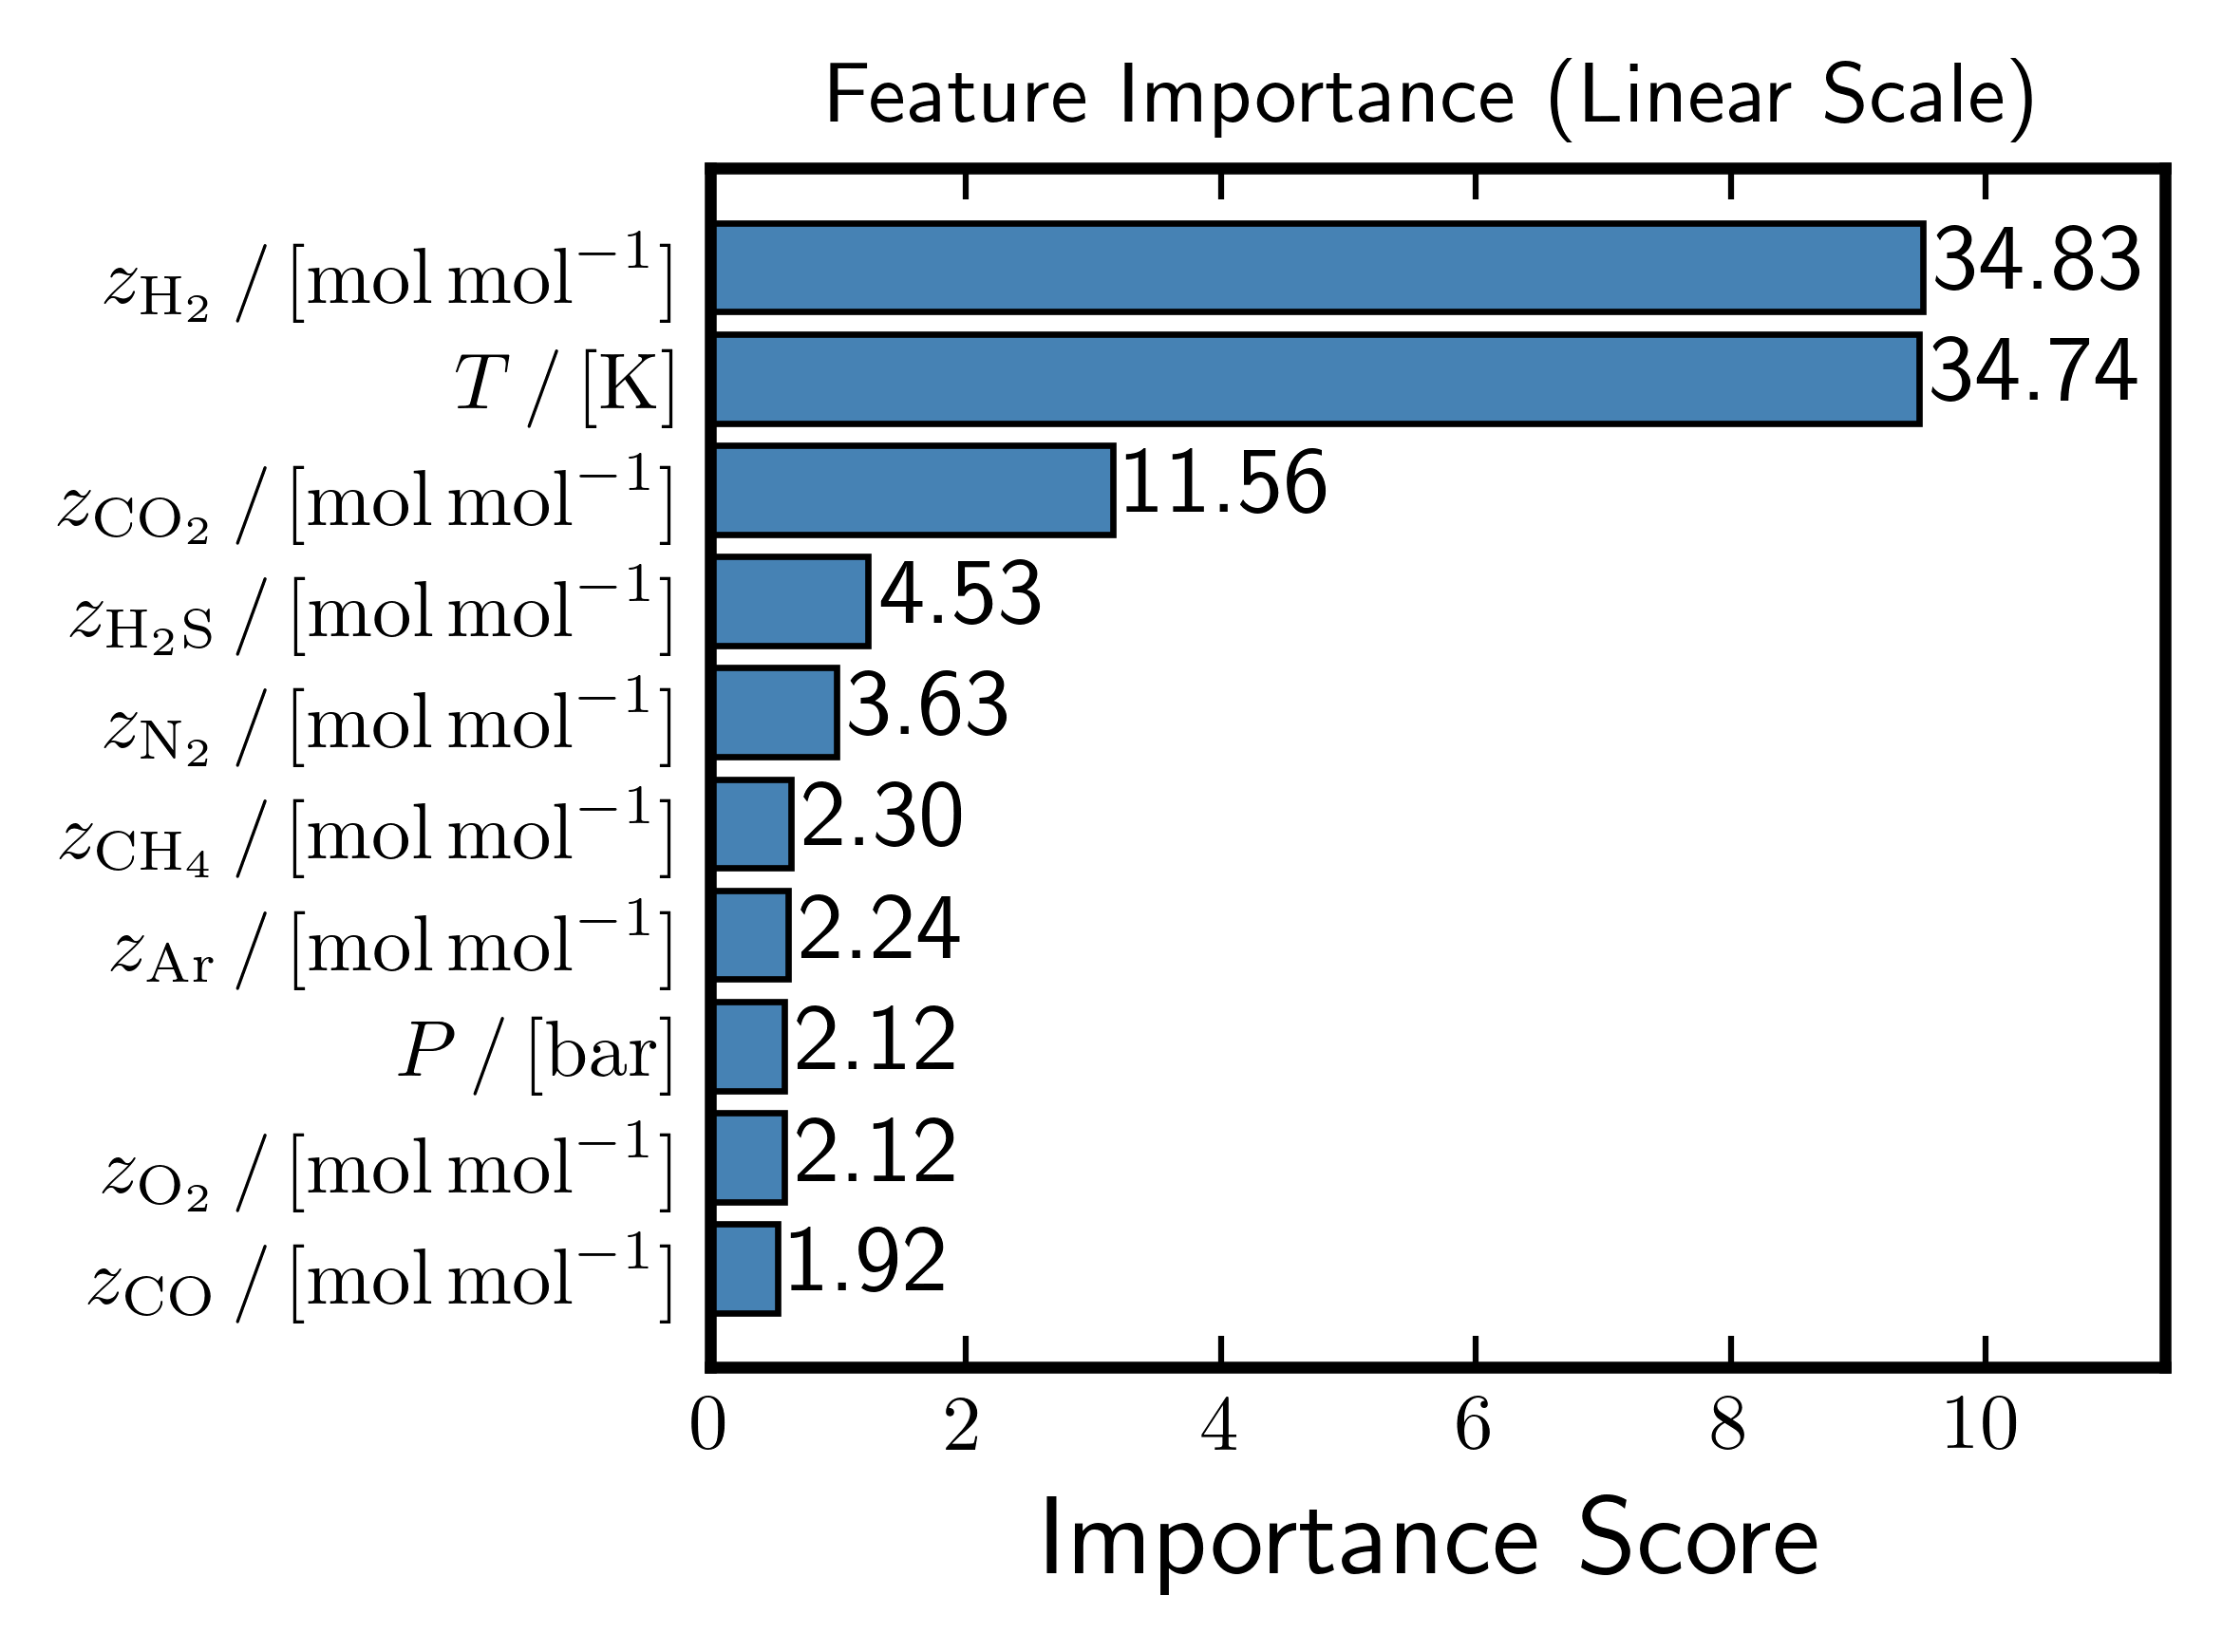

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance (Linear Scale)'}, xlabel='Importance Score'>)

In [14]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="P_bubble",
    feature_importances=feature_importances,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

# Plot feature importance (Linear Scale)
post.plot_feature_importance(scale="linear", color="steelblue", save_path=f"SVM_{target}_feature_importance_linear", folder=OUTPUT_FOLDER)


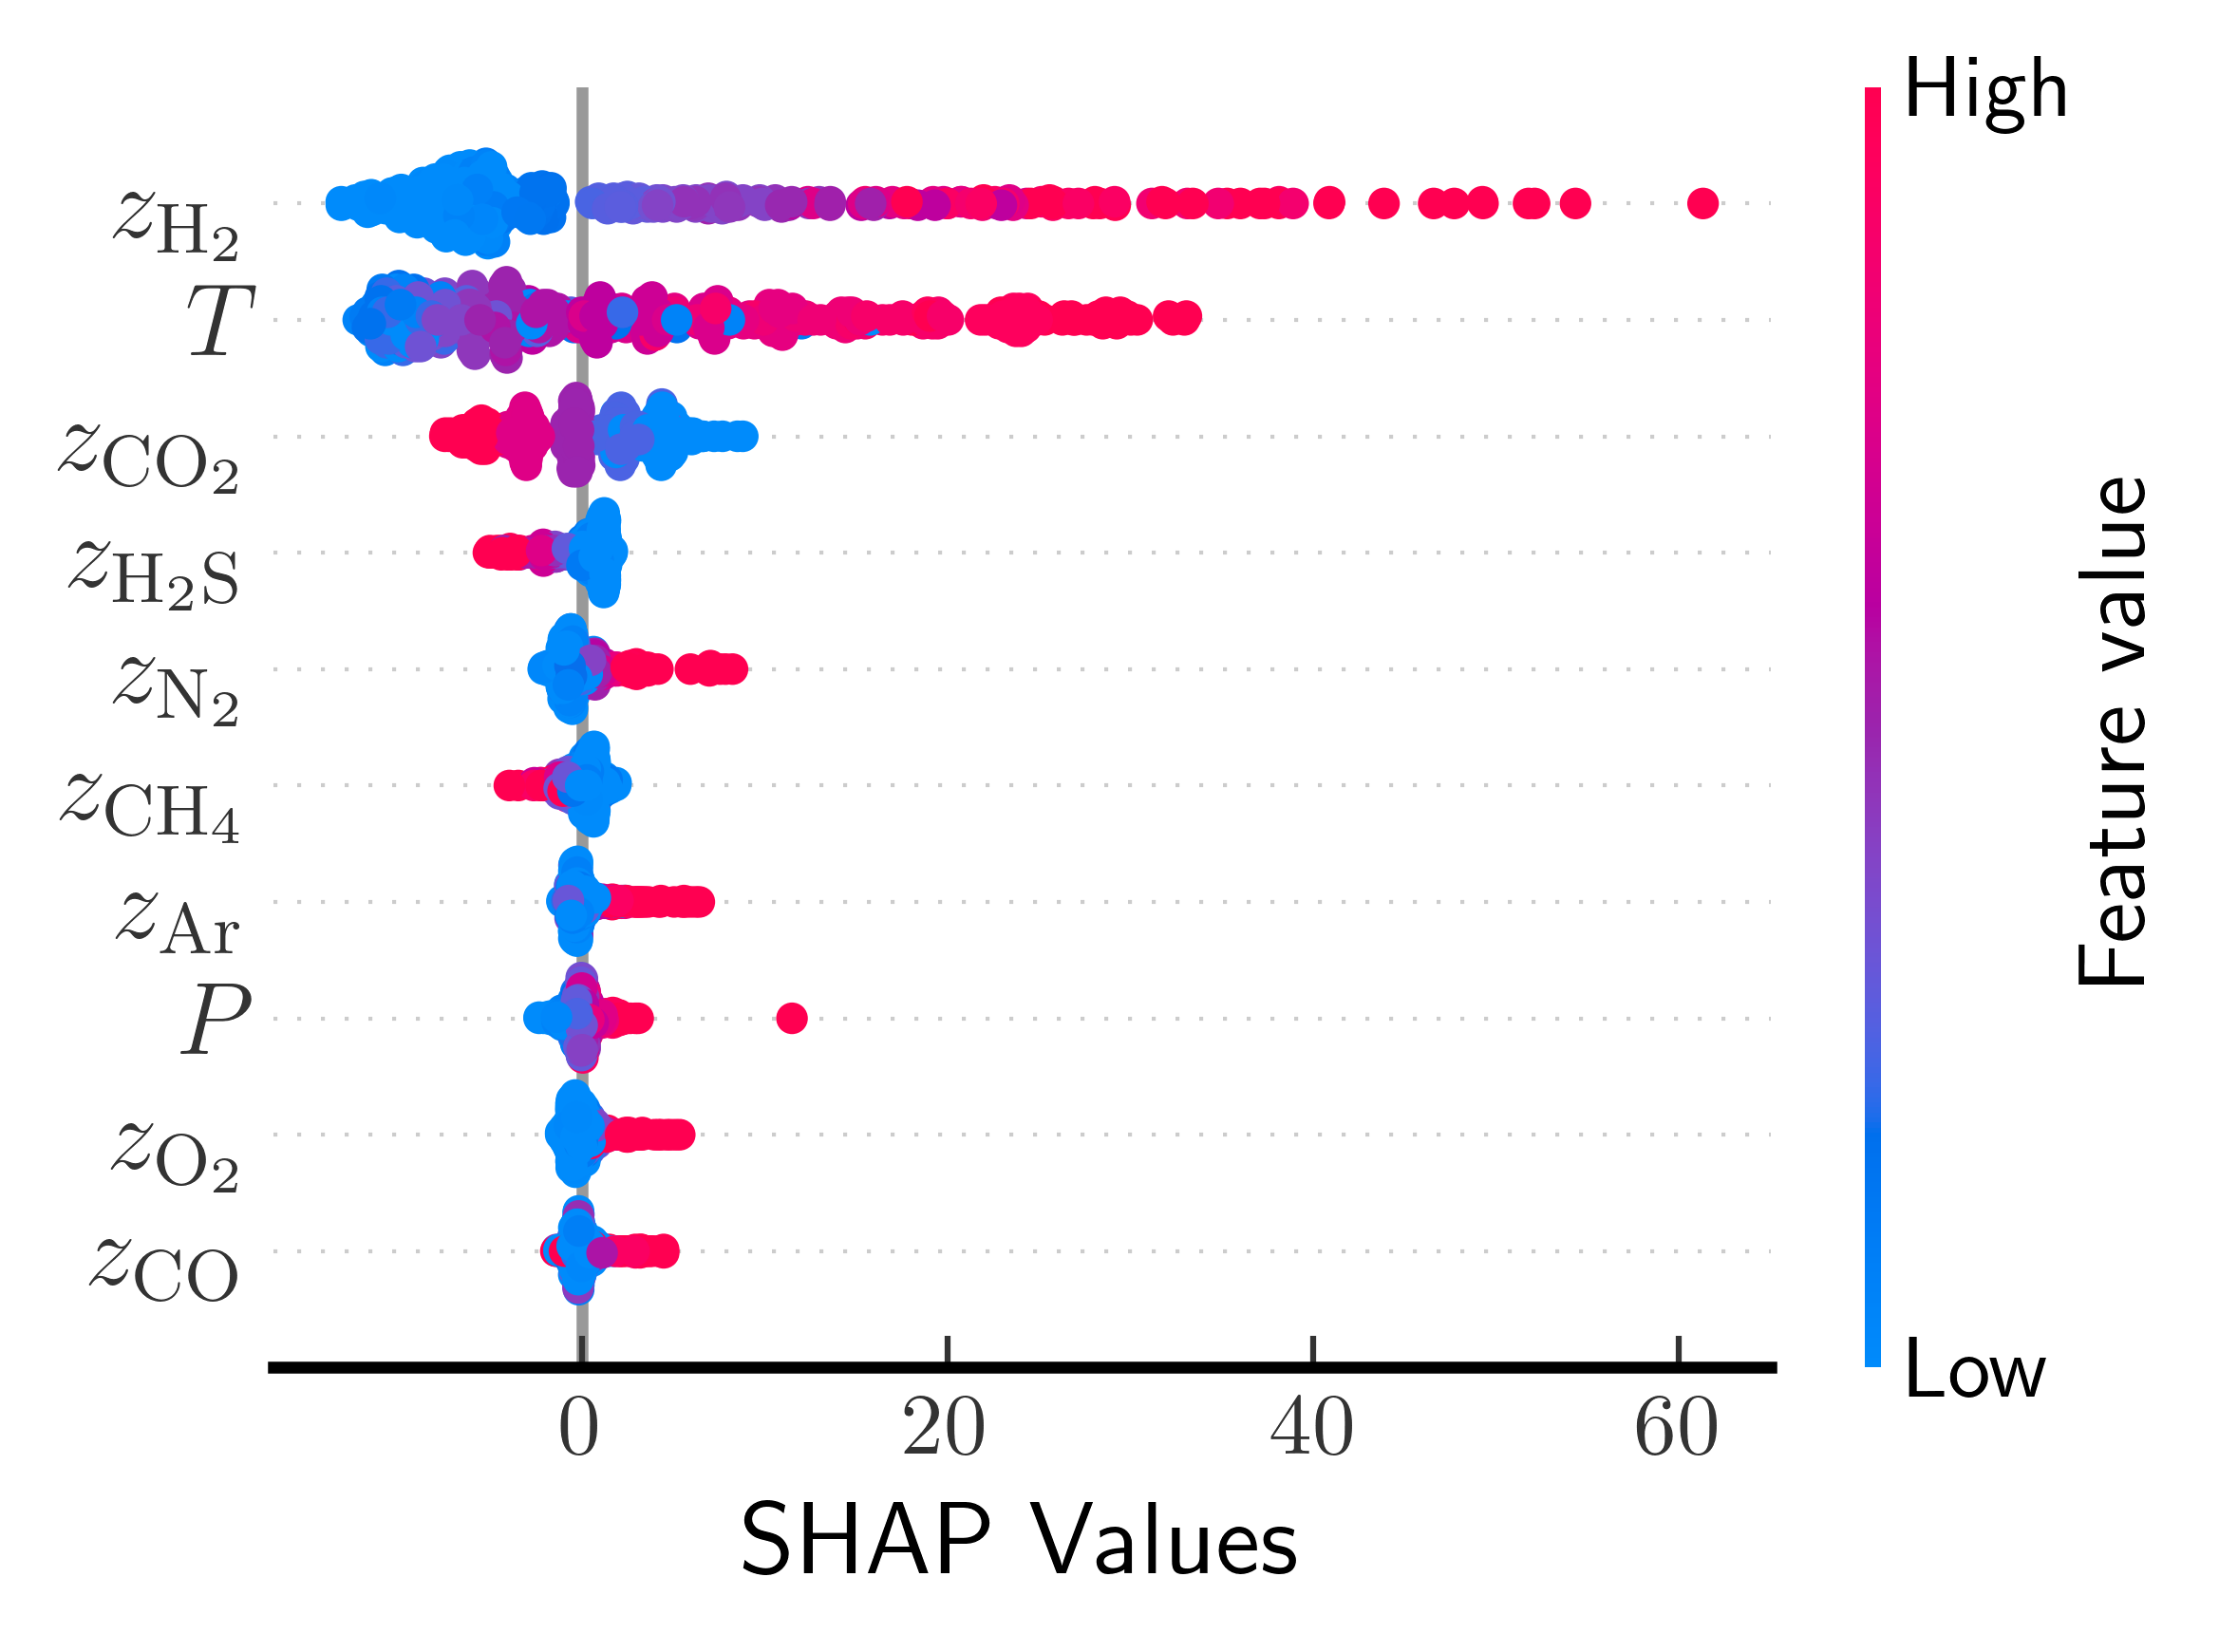

In [15]:
# SHAP Beeswarm Summary Plot
fig, ax = ps.plot_init()
shap.summary_plot(
    shap_values,
    X_test_scaled[:len(shap_df)],
    feature_names=feature_labels,
    show=False,
    plot_size=None,
)
ax = plt.gca()
ax.set_xlabel("SHAP Values")
plt.tight_layout()
ps.save_plot(fig, f"SVM_{target}_shap_summary", folder=OUTPUT_FOLDER)
plt.show()

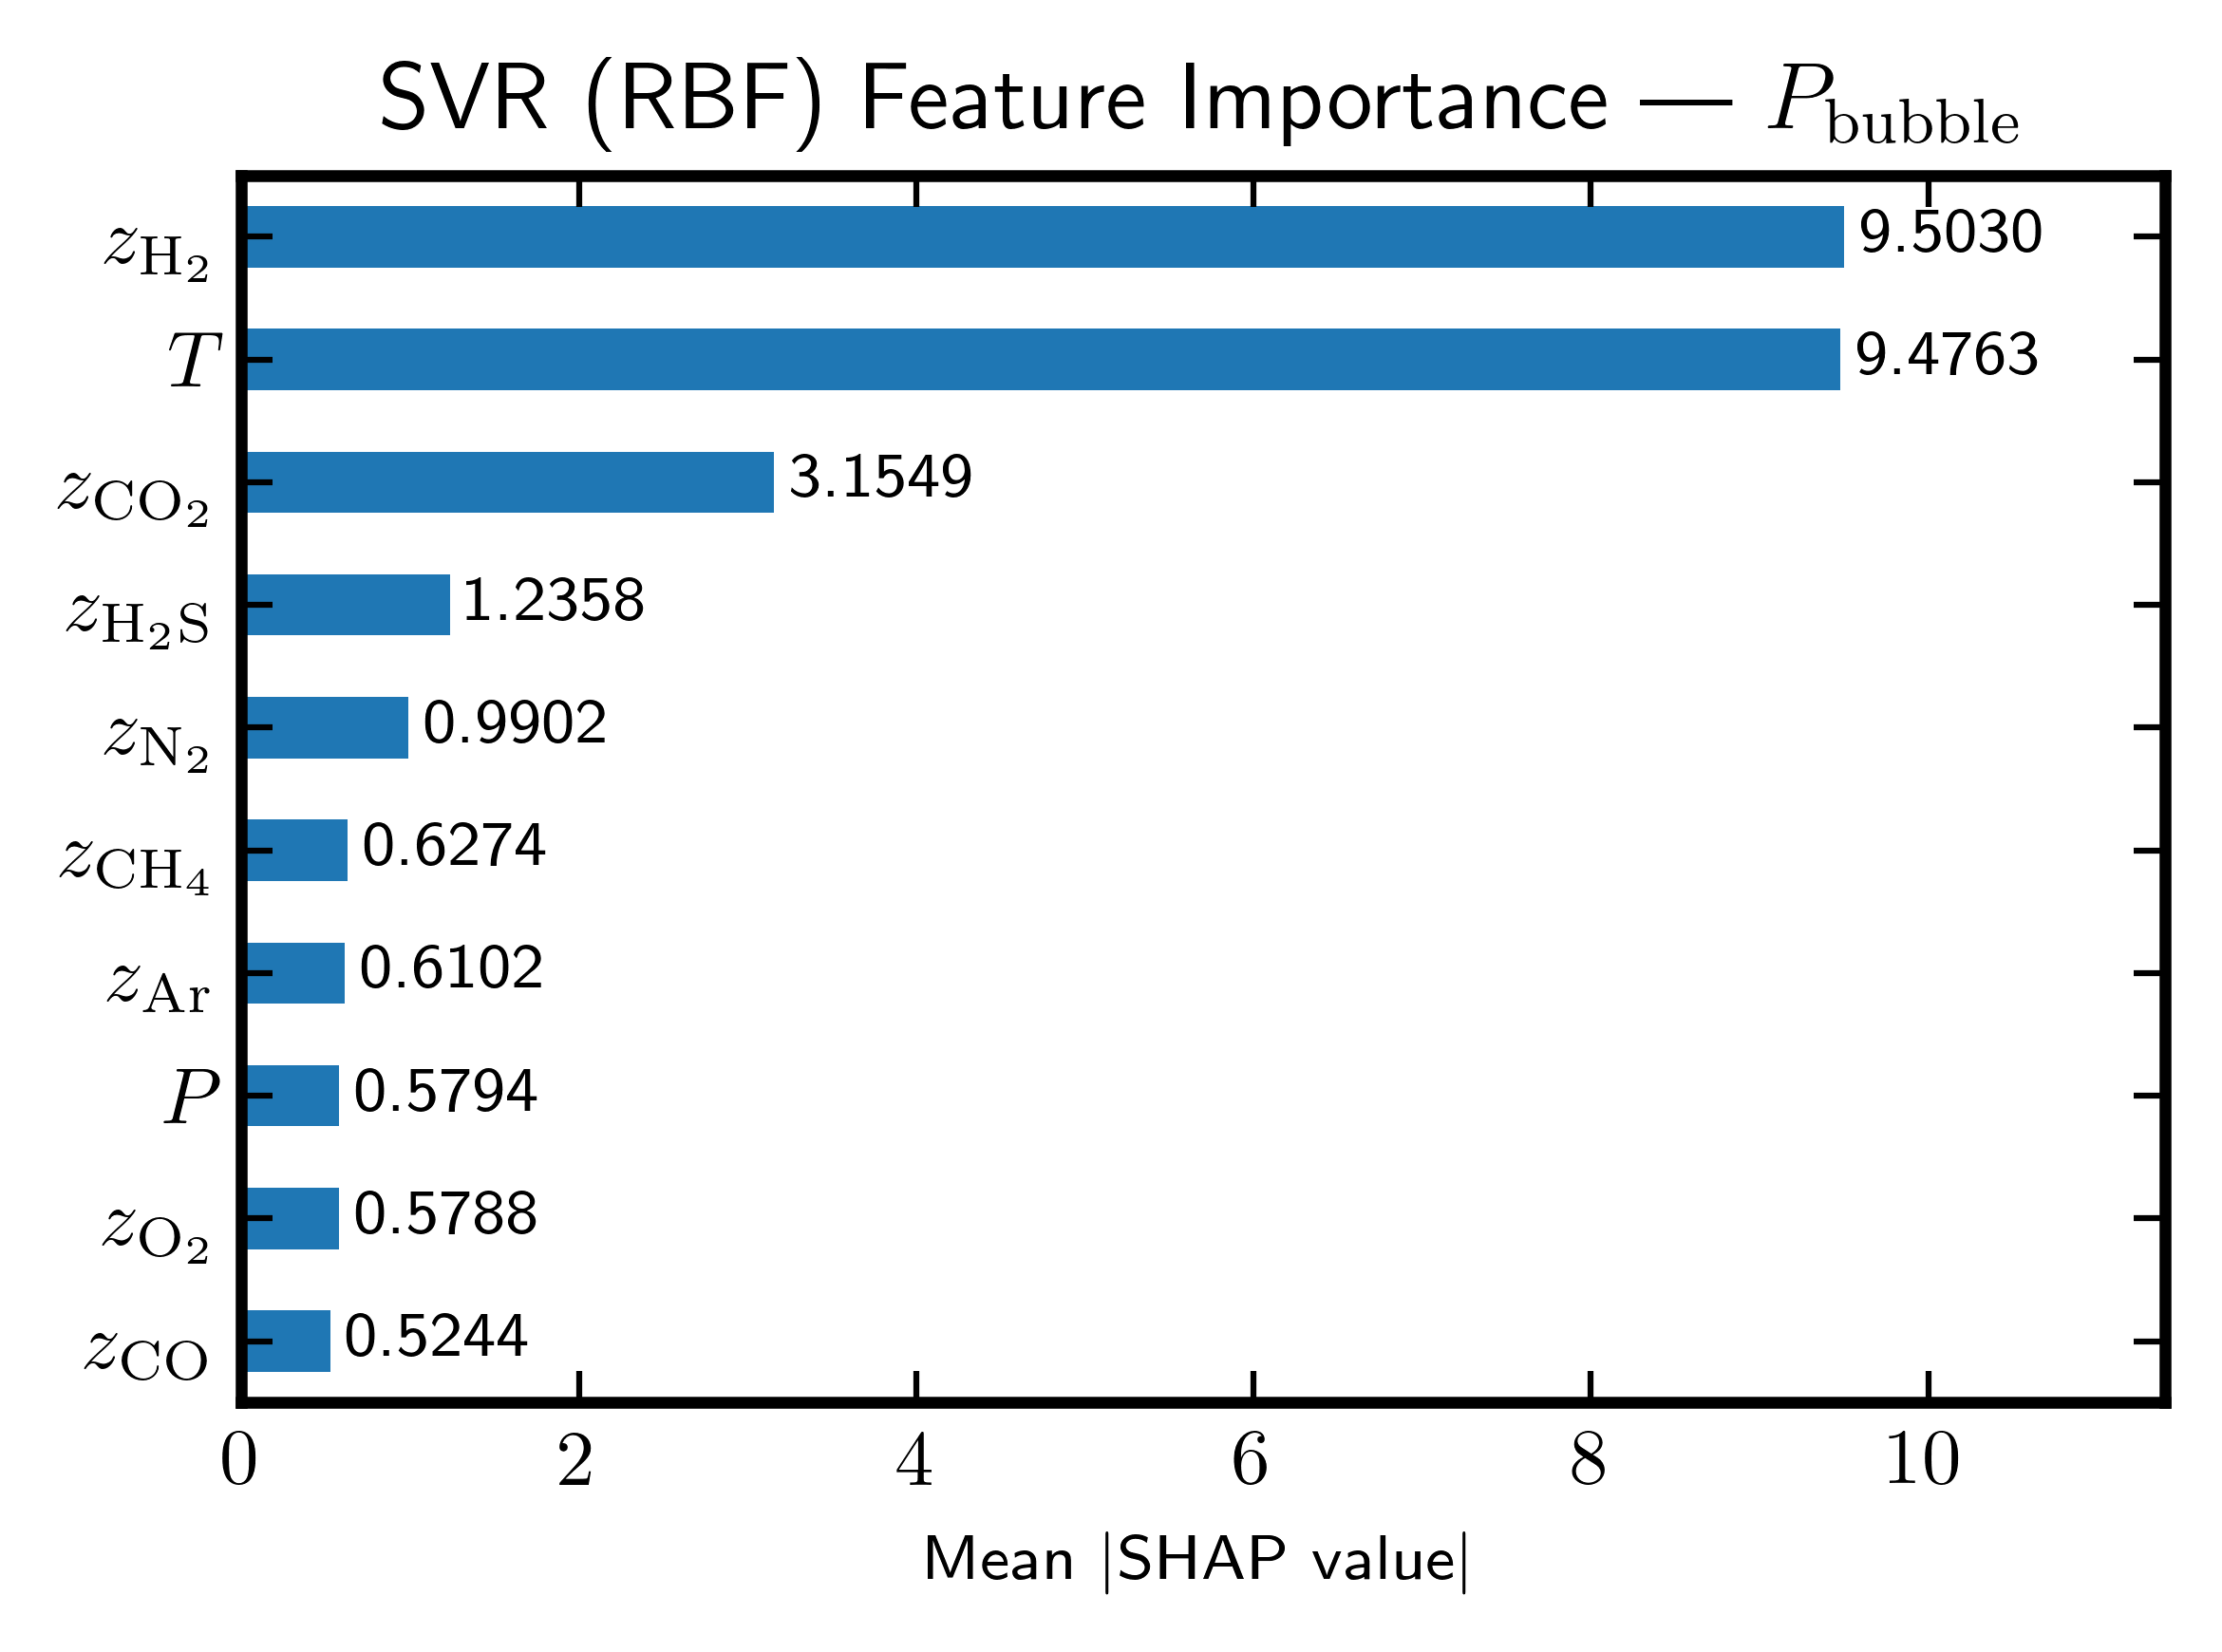

In [16]:
# Mean |SHAP| Bar Chart
mean_abs_shap = np.abs(shap_df).mean().sort_values(ascending=True)
target_label  = label_map.get(target, target)

fig, ax = ps.plot_init()
mean_abs_shap.plot(kind="barh", ax=ax)

for i, val in enumerate(mean_abs_shap):
    ax.text(
        val + 0.01 * mean_abs_shap.max(),
        i,
        f"{val:.4f}",
        va="center",
        ha="left",
        fontsize=8,
    )

ax.set_xlim(0, mean_abs_shap.max() * 1.20)
ax.set_xlabel(r"Mean $|$SHAP value$|$")
ax.set_title(f"SVR ({kernel.upper()}) Feature Importance — {target_label}")
ps.apply_axis_style(ax)
plt.tight_layout()
ps.save_plot(fig, f"SVM_{target}_shap_bar", folder=OUTPUT_FOLDER)
plt.show()

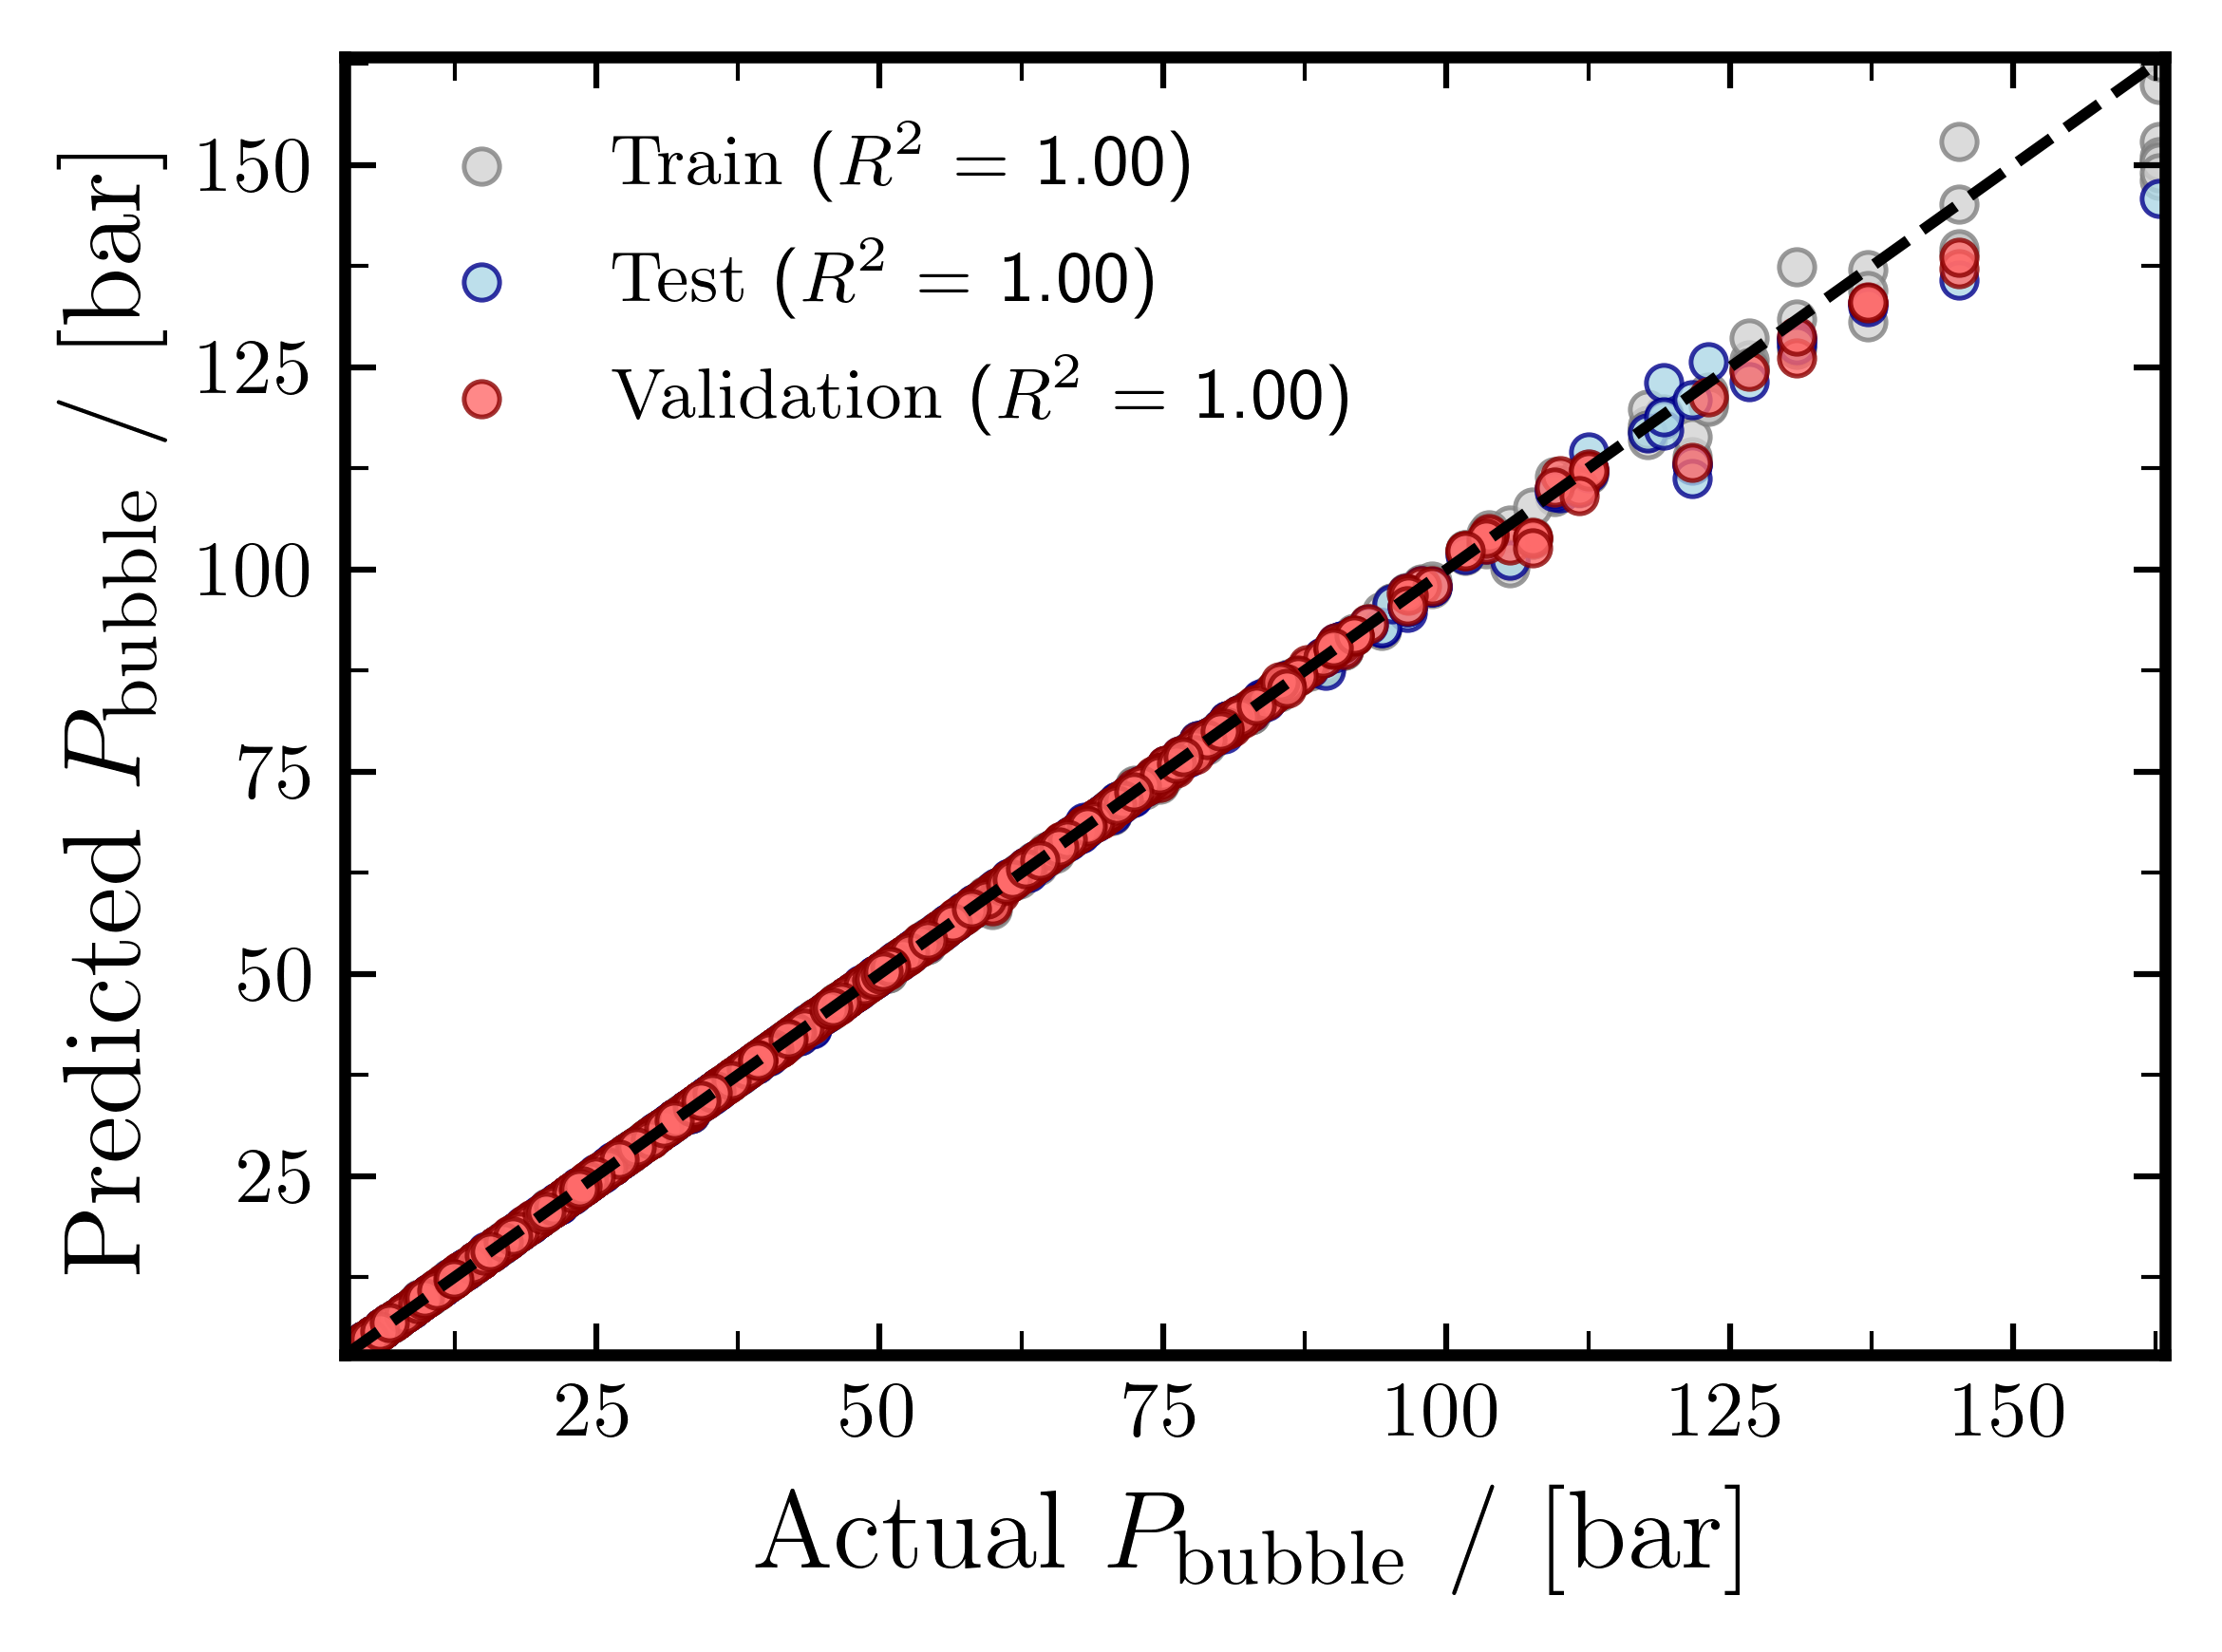

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Actual}$ $P_{\\mathrm{bubble}}$ / $[\\mathrm{bar}]$', ylabel='$\\mathrm{Predicted}$ $P_{\\mathrm{bubble}}$ / $[\\mathrm{bar}]$'>)

In [17]:
# Parity plot
post.plot_parity(model_name="SVR (Linear)", save_path="SVM_P_bubble_parity_plot", folder=OUTPUT_FOLDER)

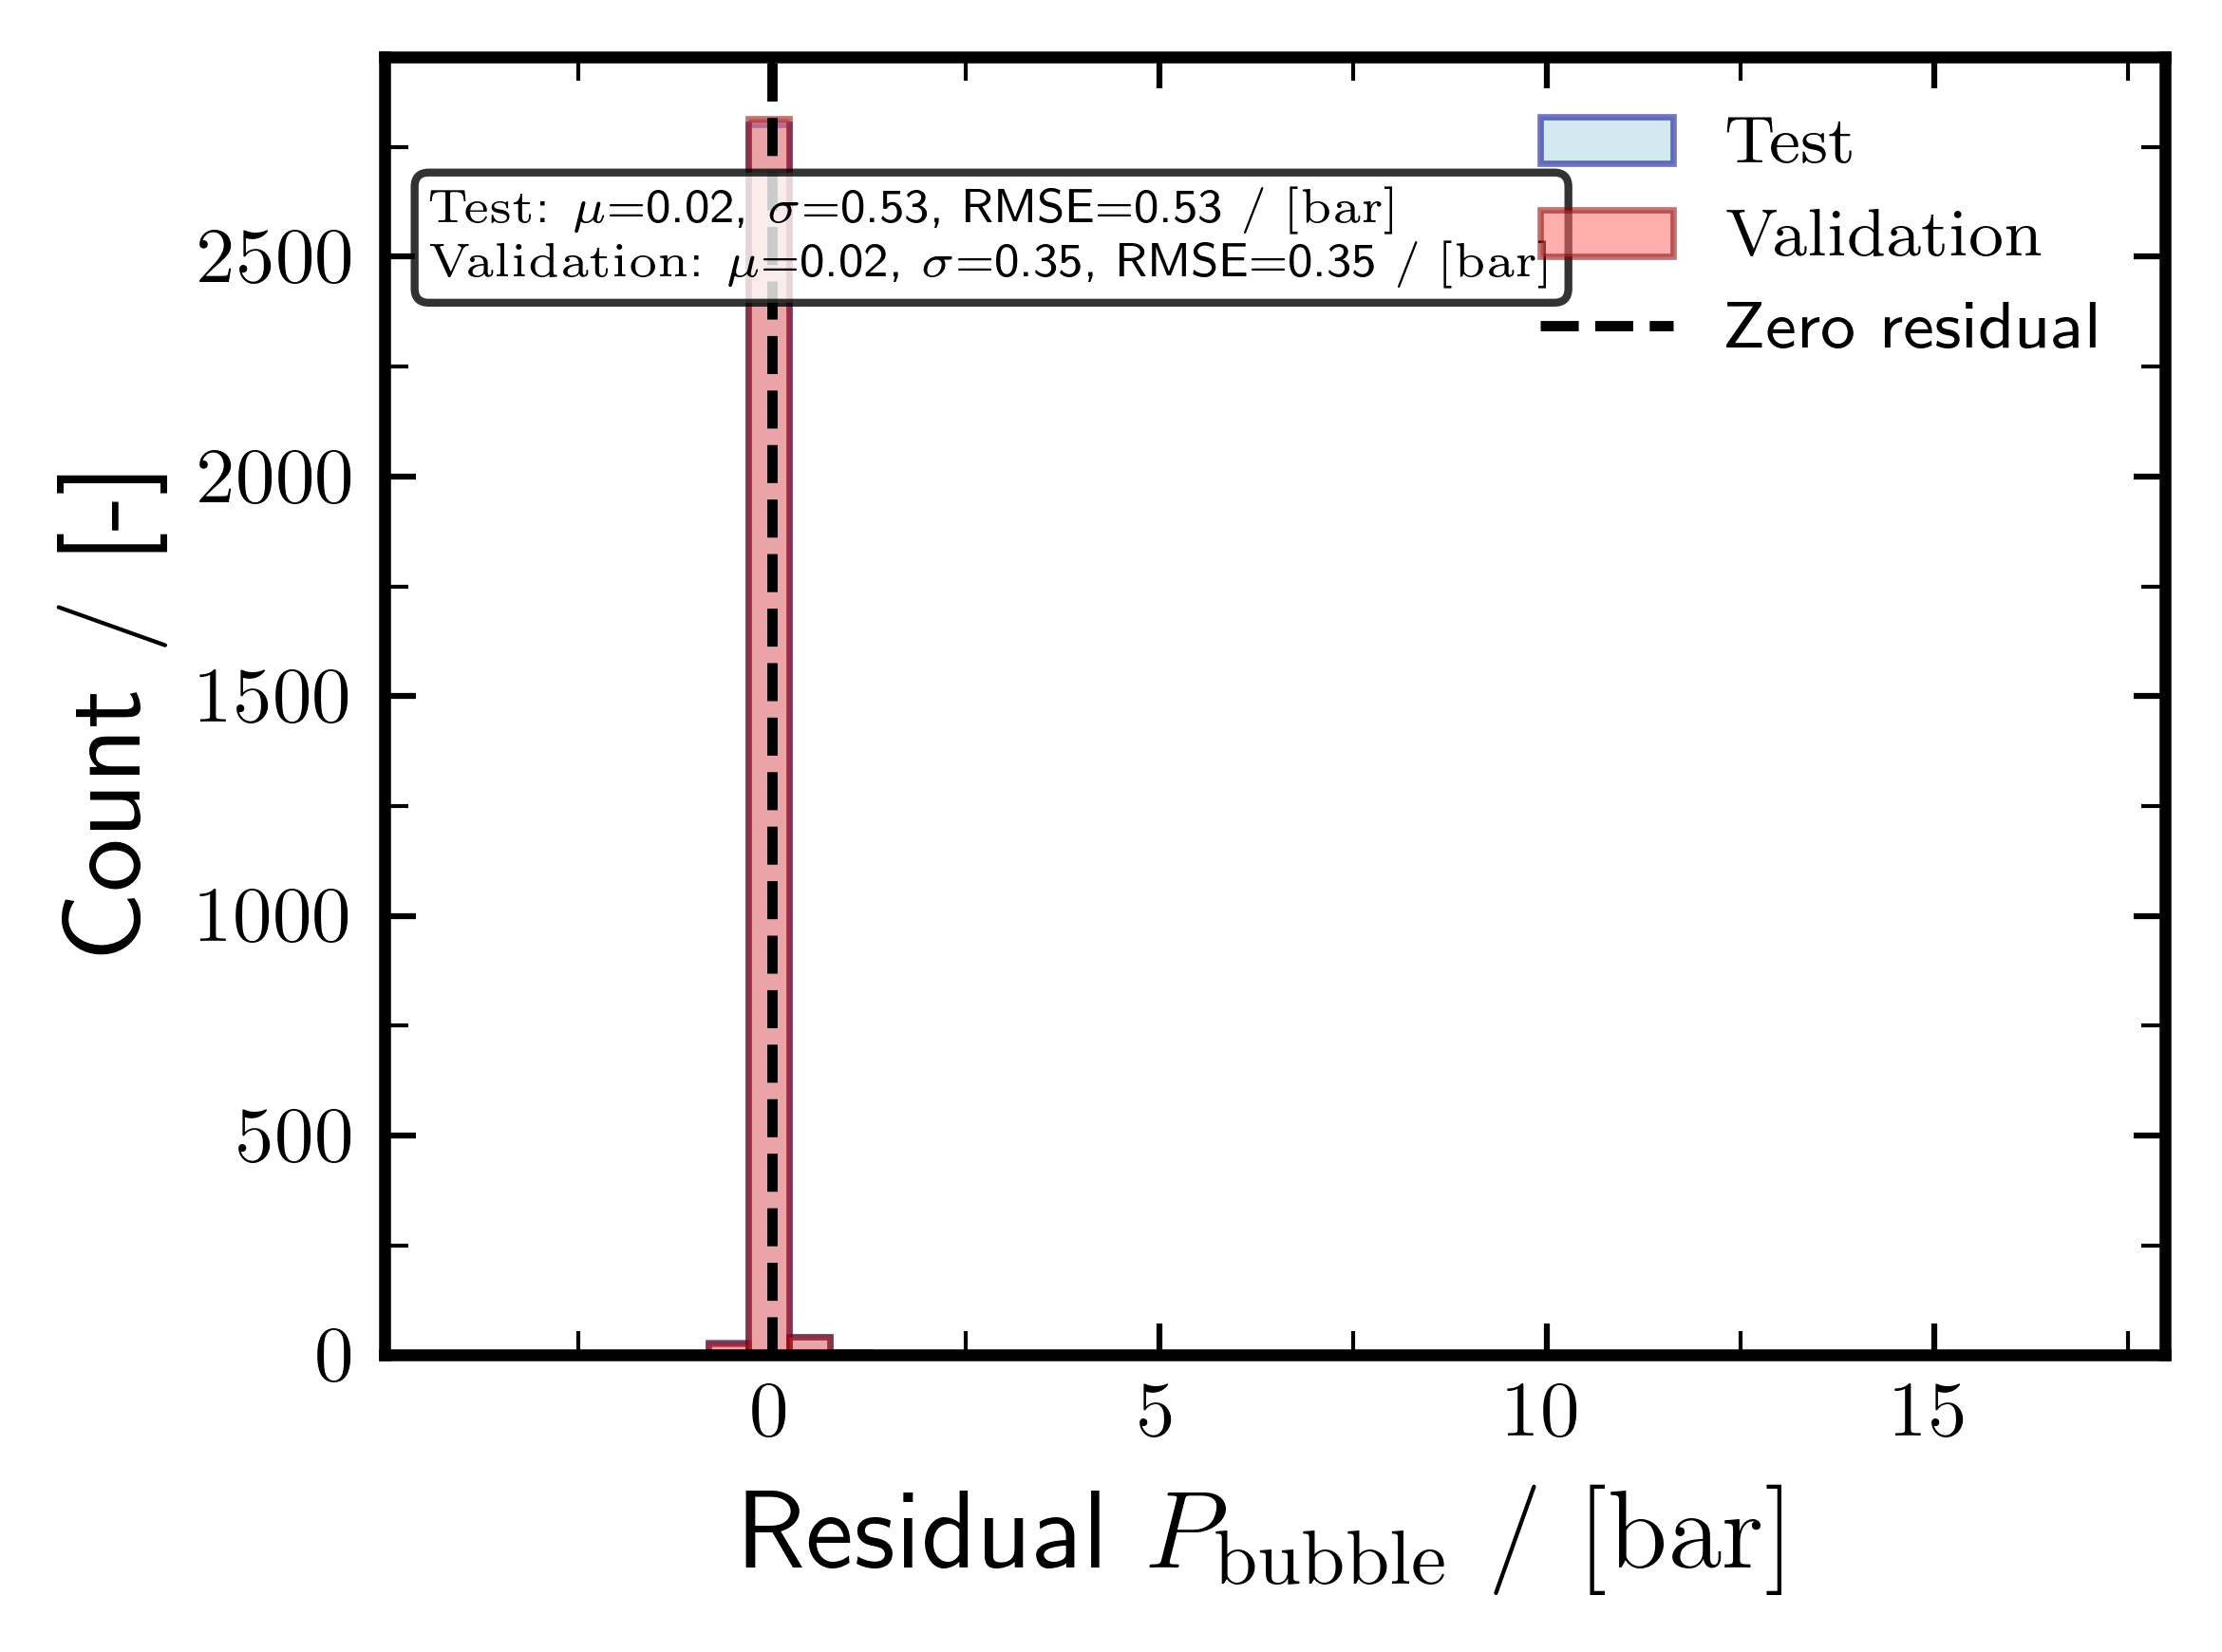

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $P_{\\mathrm{bubble}}$ / $[\\mathrm{bar}]$', ylabel='Count / [-]'>)

In [18]:
# Residual distribution
post.plot_residual_distribution(save_path="SVM_P_bubble_residual_distribution", folder=OUTPUT_FOLDER)

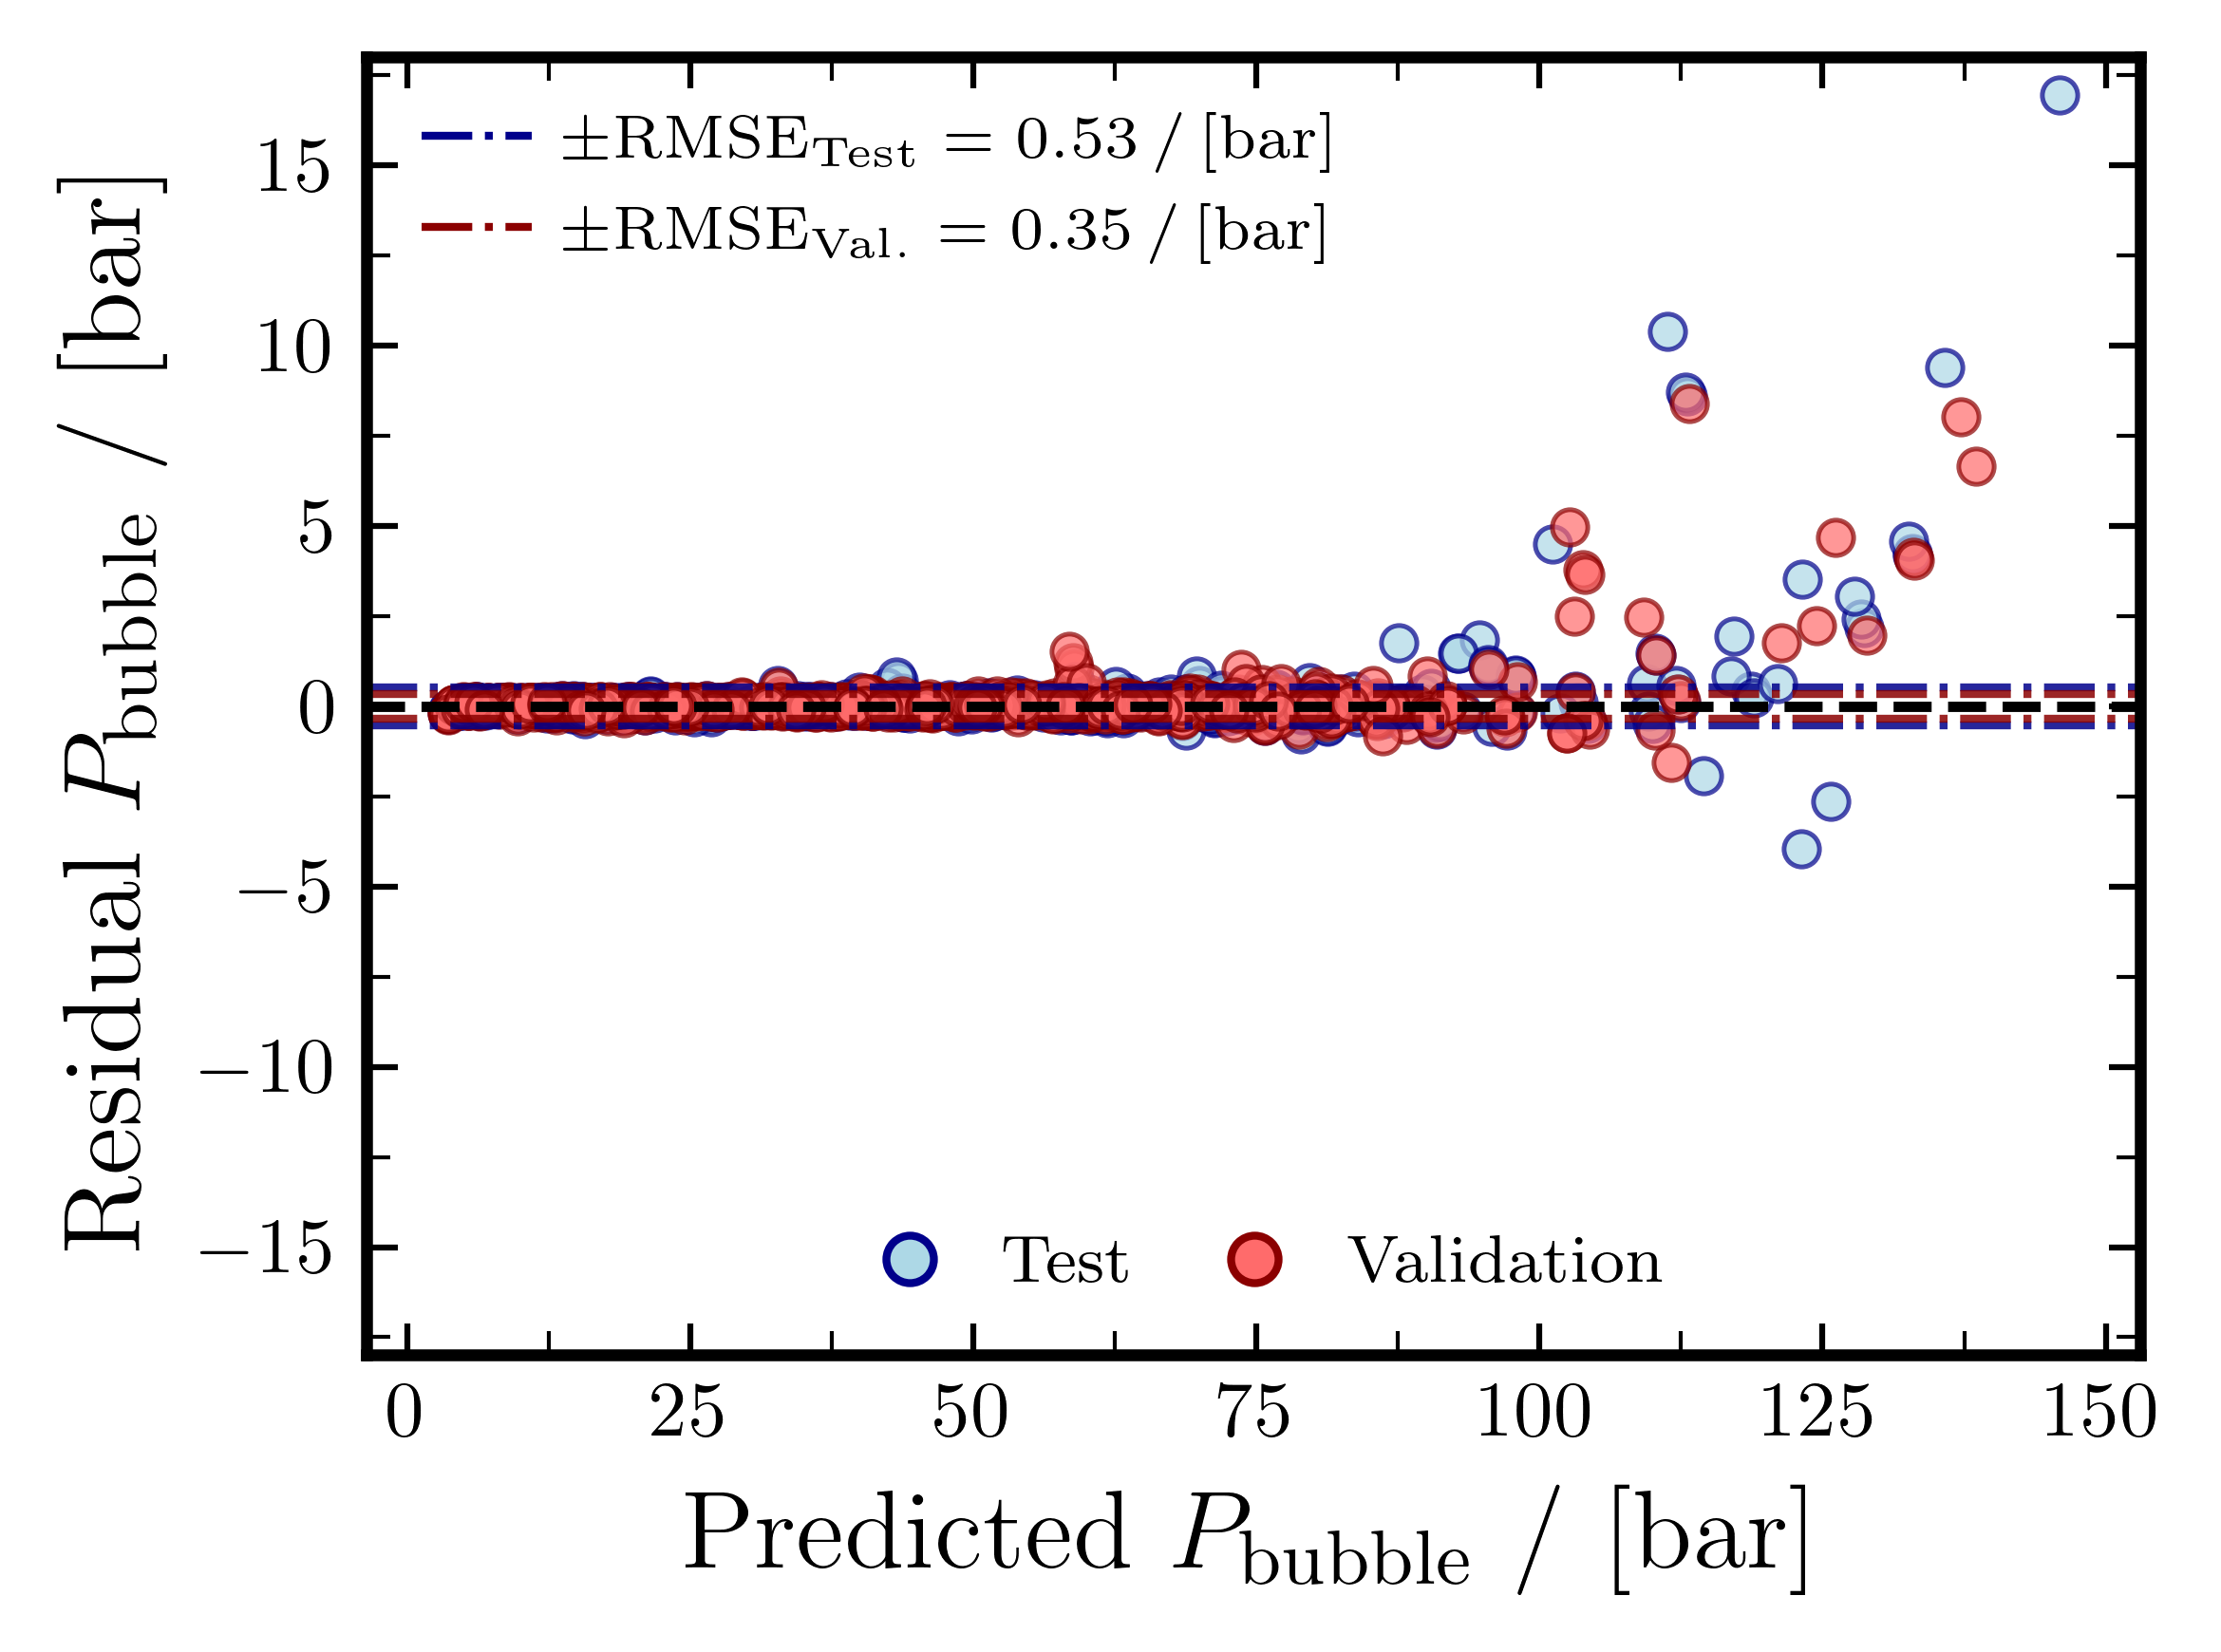

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Predicted}$ $P_{\\mathrm{bubble}}$ / $[\\mathrm{bar}]$', ylabel='$\\mathrm{Residual}$ $P_{\\mathrm{bubble}}$ / $[\\mathrm{bar}]$'>)

In [19]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="SVM_P_bubble_residual_vs_predicted",
                                y_range=[-18,18],
                                folder=OUTPUT_FOLDER)

In [20]:
post.print_summary()

# Collect and save all metrics
metrics["cv_r2_scores"]   = cv_r2_scores.tolist()
metrics["cv_r2_mean"]     = float(cv_r2_scores.mean())
metrics["cv_r2_std"]      = float(cv_r2_scores.std())
metrics["cv_rmse_scores"] = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]   = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]    = float(cv_rmse_scores.std())
metrics["cv_mae_scores"]  = cv_mae_scores.tolist()
metrics["cv_mae_mean"]    = float(cv_mae_scores.mean())
metrics["cv_mae_std"]     = float(cv_mae_scores.std())
metrics["cv_mape_scores"] = (cv_mape_scores * 100).tolist()
metrics["cv_mape_mean"]   = float(cv_mape_scores.mean() * 100)
metrics["cv_mape_std"]    = float(cv_mape_scores.std() * 100)
metrics["n_support_vectors"]  = int(svm_model.named_steps["svr"].support_vectors_.shape[0])
metrics["sv_fraction"]        = float(svm_model.named_steps["svr"].support_vectors_.shape[0] / len(X_train))
metrics["C_sweep_values"]     = C_values
metrics["C_sweep_test_rmse"]  = test_rmse_C
metrics["C_sweep_cv_rmse"]    = cv_rmse_C
metrics["eps_sweep_values"]   = eps_values
metrics["eps_sweep_test_rmse"]= test_rmse_eps
metrics["eps_sweep_cv_rmse"]  = cv_rmse_eps
metrics["model"]          = "SVR_linear"
metrics["kernel"]         = svm_model.named_steps["svr"].kernel
metrics["C"]              = svm_model.named_steps["svr"].C
metrics["epsilon"]        = svm_model.named_steps["svr"].epsilon
metrics["features"]       = features
metrics["target"]         = target
metrics["seed"]           = SEED

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"SVM_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - P_BUBBLE
Samples:        2904
R² Score:       0.999408
RMSE:           0.532407
MAE:            0.107409
Mean Residual:  0.024418
Std Residual:   0.531846

FEATURE IMPORTANCES:
------------------------------------------------------------
  z_hydrogen                |  34.83% | █████████████████
  temperature               |  34.74% | █████████████████
  z_carbon dioxide          |  11.56% | █████
  z_hydrogen sulfide        |   4.53% | ██
  z_nitrogen                |   3.63% | █
  z_methane                 |   2.30% | █
  z_argon                   |   2.24% | █
  pressure                  |   2.12% | █
  z_oxygen                  |   2.12% | █
  z_carbon monoxide         |   1.92% | 

Metrics saved to: SLURM_Pbubble/SVM_P_bubble_metrics.json


In [21]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 45.94 minutes
